# ICDAR Mini - Multilingual Text Recognition Benchmark Analysis


**Dataset:** ICDAR Mini - Multilingual Text Recognition  
**Total Samples:** 500 multilingual text images per phase  
**Task:** Multilingual optical character recognition (OCR)  
**Evaluation Metrics:** CER (Character Error Rate), WER (Word Error Rate), Cosine Similarity

## Benchmark Structure

### Phase Pa: OCR Baseline (Specialized OCR Models)
- **Models:** Azure Document Intelligence, Mistral Document AI
- **Approach:** Pure OCR on document images
- **Purpose:** Establish baseline OCR performance for multilingual text recognition

### Phase Pb: VLM Baseline (Generic Prompting)
- **Models:** GPT-5-nano, GPT-5-mini
- **Prompt:** Generic text extraction (no language-specific context)
- **Purpose:** Evaluate general-purpose VLM capabilities for multilingual OCR

### Phase Pc: VLM with Task-Aware Prompting
- **Models:** GPT-5-nano, GPT-5-mini
- **Prompt:** Multilingual-aware instructions
- **Purpose:** Evaluate impact of language-aware prompting on recognition accuracy

# 1. Imports and Metadata

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import sys
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Progress bar for long operations
from tqdm.notebook import tqdm

# Add ocr_vs_vlm to path for imports
# Get the notebook directory and add parent paths
notebook_dir = Path.cwd()
notebooks_dir = notebook_dir.parent  # 4_notebooks/
ocr_vs_vlm_base = notebooks_dir.parent.parent  # research-playground/

sys.path.insert(0, str(ocr_vs_vlm_base))
sys.path.insert(0, str(notebooks_dir))

from ocr_vs_vlm.metrics.evaluation_metrics import (
    calculate_cer,
    calculate_wer,
    compute_cosine_similarity,
    compute_anls,
    compute_exact_match,
    compute_ground_truth_in_prediction
)

# Import embedding cache manager for efficient cosine similarity computation
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager, save_embeddings_for_phase

# Define MODEL_ORDER inline (instead of importing from missing utils module)
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER, keeping any unknown models at the end."""
    known = [m for m in MODEL_ORDER if m in models]
    unknown = [m for m in models if m not in MODEL_ORDER]
    return known + unknown

def get_model_display_name(model: str) -> str:
    """Get display name for a model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral Document AI',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet'
    }
    return display_names.get(model, model)

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

print("✓ Imports loaded successfully")
print(f"✓ Model display order: {', '.join(MODEL_ORDER)}")
print(f"✓ Working directory: {notebook_dir}")
print(f"✓ Utils path added: {notebooks_dir}")

✓ Imports loaded successfully
✓ Model display order: azure_intelligence, mistral_document_ai, gpt-5-nano, gpt-5-mini, claude_sonnet
✓ Working directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/4_notebooks/by_dataset
✓ Utils path added: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/4_notebooks


### Load Phase Data

In [64]:
# Data paths
data_dir = Path("../../2_clean/ICDAR_mini")

# Load phase files
df_pa = pd.read_csv(data_dir / "Pa.csv")
df_pb = pd.read_csv(data_dir / "Pb.csv")
df_pc = pd.read_csv(data_dir / "Pc.csv")

print(f"Phase A (OCR baseline): {len(df_pa)} samples")
print(f"Phase B (VLM baseline): {len(df_pb)} samples")
print(f"Phase C (VLM + context): {len(df_pc)} samples")

# Display column names for reference
print("\nPhase A columns:", df_pa.columns.tolist())
print("Phase B columns:", df_pb.columns.tolist())
print("Phase C columns:", df_pc.columns.tolist())

Phase A (OCR baseline): 491 samples
Phase B (VLM baseline): 491 samples
Phase C (VLM + context): 491 samples

Phase A columns: ['sample_id', 'image_path', 'ground_truth', 'language', 'dataset', 'prediction_azure_intelligence', 'inference_time_ms_azure_intelligence', 'tokens_used_azure_intelligence', 'error_azure_intelligence', 'prediction_mistral_document_ai', 'inference_time_ms_mistral_document_ai', 'tokens_used_mistral_document_ai', 'error_mistral_document_ai']
Phase B columns: ['sample_id', 'image_path', 'ground_truth', 'language', 'dataset', 'prediction_gpt-5-mini', 'inference_time_ms_gpt-5-mini', 'tokens_used_gpt-5-mini', 'error_gpt-5-mini', 'prediction_gpt-5-nano', 'inference_time_ms_gpt-5-nano', 'tokens_used_gpt-5-nano', 'error_gpt-5-nano']
Phase C columns: ['sample_id', 'image_path', 'ground_truth', 'language', 'dataset', 'prediction_gpt-5-mini', 'inference_time_ms_gpt-5-mini', 'tokens_used_gpt-5-mini', 'error_gpt-5-mini', 'prediction_gpt-5-nano', 'inference_time_ms_gpt-5-nano'

### Load embeddings

In [65]:
# Dataset configuration
DATASET_NAME = "ICDAR_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"\n📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")


📁 Dataset: ICDAR_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: Pa, Pb, Pc


### Check dataset and metadata

In [66]:
# Load enhanced metadata from original ICDAR dataset for better language classification
from ocr_vs_vlm.datasets.dataset_loaders import ICDARDataset

# Path to original ICDAR dataset
icdar_root = Path("/Users/kenzabenkirane/Documents/GitHub/research-playground/datasets/task1_parsing/ICDAR")

print("🔍 Loading enhanced metadata from original ICDAR dataset...")
print(f"   ICDAR root path: {icdar_root.resolve()}")

try:
    # Load the full ICDAR dataset to get enhanced metadata
    icdar_dataset = ICDARDataset(str(icdar_root), sample_limit=None)
    
    # Create metadata mapping
    enhanced_metadata = {}
    for sample in icdar_dataset.samples:
        enhanced_metadata[sample.sample_id] = {
            'languages_list': sample.metadata.get('languages', []),
            'language_string': sample.metadata.get('language', ''),
            'num_text_lines': sample.metadata.get('num_text_lines', 0),
            'image_size': sample.metadata.get('image_size', (0, 0)),
            'bounding_boxes': sample.metadata.get('bounding_boxes', []),
            'image_width': sample.metadata.get('image_size', (0, 0))[0],
            'image_height': sample.metadata.get('image_size', (0, 0))[1],
        }
    
    print(f"✅ Loaded enhanced metadata for {len(enhanced_metadata)} samples")
    print("📊 Additional metadata fields available:")
    print("   - languages_list: List of unique languages per image")
    print("   - num_text_lines: Number of text regions in image")
    print("   - image_size: (width, height) of image")
    print("   - bounding_boxes: List of bounding box coordinates for each text region")
    
    # Merge enhanced metadata into dataframes
    def add_enhanced_metadata(df):
        df_copy = df.copy()
        for idx, row in df_copy.iterrows():
            sample_id = row['sample_id']
            if sample_id in enhanced_metadata:
                meta = enhanced_metadata[sample_id]
                df_copy.at[idx, 'languages_list'] = str(meta['languages_list'])  # Convert to string for storage
                df_copy.at[idx, 'num_text_lines'] = meta['num_text_lines']
                df_copy.at[idx, 'image_width'] = meta['image_width']
                df_copy.at[idx, 'image_height'] = meta['image_height']
                df_copy.at[idx, 'bounding_boxes'] = str(meta['bounding_boxes'])  # Convert to string for storage
        return df_copy
    
    df_pa = add_enhanced_metadata(df_pa)
    df_pb = add_enhanced_metadata(df_pb)
    df_pc = add_enhanced_metadata(df_pc)
    
    print("✅ Enhanced metadata merged into all phase dataframes")
    
except Exception as e:
    print(f"⚠️ Could not load enhanced metadata: {e}")
    print("   Proceeding with basic metadata only")
    enhanced_metadata = {}

🔍 Loading enhanced metadata from original ICDAR dataset...
   ICDAR root path: /Users/kenzabenkirane/Documents/GitHub/research-playground/datasets/task1_parsing/ICDAR
✅ Loaded enhanced metadata for 9996 samples
📊 Additional metadata fields available:
   - languages_list: List of unique languages per image
   - num_text_lines: Number of text regions in image
   - image_size: (width, height) of image
   - bounding_boxes: List of bounding box coordinates for each text region
✅ Enhanced metadata merged into all phase dataframes


### Data Quality Assessment

Identify and count rows with empty predictions or errors. These will be excluded from all metric calculations.

In [67]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

# Define phase_dfs dictionary
phase_dfs = {'Pa': df_pa, 'Pb': df_pb, 'Pc': df_pc}

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 Pa - Total rows: 491
  azure_intelligence:
    ✅ Valid rows: 491/491 (100.0%)
  mistral_document_ai:
    ✅ Valid rows: 491/491 (100.0%)

📊 Pb - Total rows: 491
  gpt-5-mini:
    ✅ Valid rows: 491/491 (100.0%)
  gpt-5-nano:
    ✅ Valid rows: 491/491 (100.0%)

📊 Pc - Total rows: 491
  gpt-5-mini:
    ✅ Valid rows: 491/491 (100.0%)
  gpt-5-nano:
    ✅ Valid rows: 491/491 (100.0%)

QUALITY SUMMARY - Models with Issues
✅ All models have 100% valid data - no filtering needed!



### Metric calculation

In [72]:
# Chunking function for multilingual text (smaller chunks than English)
def chunk_text(text: str, chunk_size: int = 150, overlap: int = 30) -> List[str]:
    """Chunk text into overlapping segments for long multilingual documents."""
    if pd.isna(text) or text == "":
        return []
    chunks = []
    start = 0
    text = str(text)
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        if end == len(text):
            break
        start += (chunk_size - overlap)
    return chunks if chunks else [text]

# Helper function to calculate metrics for a single prediction (using embedding cache with multilingual chunking)
def calculate_sample_metrics(
    ground_truth: str, 
    prediction: str,
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager
) -> Dict[str, float]:
    """Calculate all metrics for a single sample with cached embeddings and multilingual chunking."""
    if pd.isna(prediction) or prediction == "":
        return {
            'cer': 1.0,
            'wer': 1.0,
            'anls': 0.0,
            'cosine_similarity': 0.0,
            'ground_truth_in_prediction': 0.0,
        }
    
    gt_str = str(ground_truth)
    pred_str = str(prediction)
    
    # For multilingual text >300 chars, use chunking for cosine similarity
    # Use smaller chunks (150 chars with 30 char overlap) for multilingual content
    if len(gt_str) > 300 or len(pred_str) > 300:
        gt_chunks = chunk_text(gt_str, chunk_size=150, overlap=30)
        pred_chunks = chunk_text(pred_str, chunk_size=150, overlap=30)
        
        # Compute cosine similarity for each pair of chunks
        chunk_similarities = []
        max_chunks = max(len(gt_chunks), len(pred_chunks))
        
        for i in range(max_chunks):
            gt_chunk = gt_chunks[i] if i < len(gt_chunks) else gt_chunks[-1]
            pred_chunk = pred_chunks[i] if i < len(pred_chunks) else pred_chunks[-1]
            
            # Use chunk-specific sample_id for caching
            chunk_sample_id = f"{sample_id}_chunk{i}"
            chunk_sim = emb_manager.compute_cosine_similarity(
                phase=phase,
                ground_truth=gt_chunk,
                prediction=pred_chunk,
                sample_id=chunk_sample_id,
                model=model
            )
            chunk_similarities.append(chunk_sim)
        
        # Average chunk similarities
        cosine_sim = np.mean(chunk_similarities)
    else:
        # For shorter texts (≤300 chars), compute directly without chunking
        cosine_sim = emb_manager.compute_cosine_similarity(
            phase=phase,
            ground_truth=gt_str,
            prediction=pred_str,
            sample_id=sample_id,
            model=model
        )
    

    return {
        'cer': calculate_cer(gt_str, pred_str),
        'wer': calculate_wer(gt_str, pred_str),
        'anls': compute_anls(pred_str, [gt_str]),
        'cosine_similarity': cosine_sim,
        'ground_truth_in_prediction': compute_ground_truth_in_prediction(pred_str, [gt_str]),
    }


In [73]:
# Calculate metrics for all phases and models
# Use phase dictionaries for unified iteration
phase_dfs = {'Pa': df_pa, 'Pb': df_pb, 'Pc': df_pc}
all_results = []

for phase, df in phase_dfs.items():
    print(f"\n📊 Calculating metrics for {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        valid_rows = []
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        print(f"   Processing model: {model}")
        print(f"   Using {len(valid_rows)}/{len(df)} valid rows (excluding {len(df)-len(valid_rows)} empty/error rows)")
        
        # Calculate metrics for each valid sample with progress bar
        for row in tqdm(valid_rows, total=len(valid_rows), desc=f"   {model}", leave=False):
            metrics = calculate_sample_metrics(
                ground_truth=row['ground_truth'],
                prediction=row[pred_col],
                phase=phase,
                sample_id=row['sample_id'],
                model=model,
                emb_manager=embedding_manager
            )
            
            # Get language from enhanced metadata if available, otherwise use original
            sample_id = row['sample_id']
            if enhanced_metadata and sample_id in enhanced_metadata:
                language_info = enhanced_metadata[sample_id]['languages_list']
                language_str = ', '.join(language_info) if language_info else 'unknown'
            else:
                language_str = row.get('language', 'unknown')
            
            all_results.append({
                'sample_id': row['sample_id'],
                'phase': phase,
                'model': model,
                'language': language_str,
                'cer': metrics['cer'],
                'wer': metrics['wer'],
                'anls': metrics['anls'],
                'cosine_similarity': metrics['cosine_similarity'],
                'ground_truth_in_prediction': metrics['ground_truth_in_prediction'],
                'valid_samples': len(valid_rows),
                'total_samples': len(df)
            })

# Create results DataFrame
df_results = pd.DataFrame(all_results)

print(f"\n✓ Calculated metrics for {len(df_results)} predictions")
print(f"  Models: {df_results['model'].nunique()}")
print(f"  Phases: {df_results['phase'].nunique()}")
print(f"  Languages: {df_results['language'].nunique()}")

# Save embeddings incrementally
for phase in phase_dfs.keys():
    if phase in embedding_manager.modified_phases:
        print(f"   💾 Saving embeddings for {phase}...")
        saved_file = save_embeddings_for_phase(
            dataset_name=DATASET_NAME,
            phase=phase,
            embeddings_dict=embedding_manager.cache.get(phase, {}),
            embeddings_base_dir=EMBEDDINGS_DIR
        )
        print(f"   ✅ Saved: {saved_file.name}")

print("\n✅ Metrics calculation complete!")


📊 Calculating metrics for Pa...
   Processing model: azure_intelligence
   Using 491/491 valid rows (excluding 0 empty/error rows)


   azure_intelligence:   0%|          | 0/491 [00:00<?, ?it/s]

Identical embeddings for sample icdar_tr_img_09607, model azure_intelligence


   Processing model: mistral_document_ai
   Using 491/491 valid rows (excluding 0 empty/error rows)


   mistral_document_ai:   0%|          | 0/491 [00:00<?, ?it/s]

...

Identical embeddings for sample icdar_tr_img_00916, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_00986, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_02324, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_03039, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_03137, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_03314, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_03369, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_03645, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_03863, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_03989, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_04520, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_05518, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_05542, model gpt-5-mini
Identical embeddings for sample icdar_tr_img_05658, model gpt-5-mini
Identical embeddings for sample ic

   Processing model: gpt-5-nano
   Using 491/491 valid rows (excluding 0 empty/error rows)


   gpt-5-nano:   0%|          | 0/491 [00:00<?, ?it/s]

Identical embeddings for sample icdar_tr_img_00916, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_00986, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_02324, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_03039, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_03137, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_03314, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_03369, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_03645, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_03863, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_03989, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_04520, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_05518, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_05542, model gpt-5-nano
Identical embeddings for sample icdar_tr_img_05658, model gpt-5-nano
Identical embeddings for sample ic


✓ Calculated metrics for 2946 predictions
  Models: 4
  Phases: 3
  Languages: 65

✅ Metrics calculation complete!


# 2. Statistics

### Language Distribution

Language Distribution (from original ICDAR dataset, excluding 'latin'):
Arabic       60
Bangla       59
Chinese      66
Hindi        61
Japanese     90
Korean       94
Mixed        55
None        145
Symbols      88
Name: count, dtype: int64

Total unique languages: 9


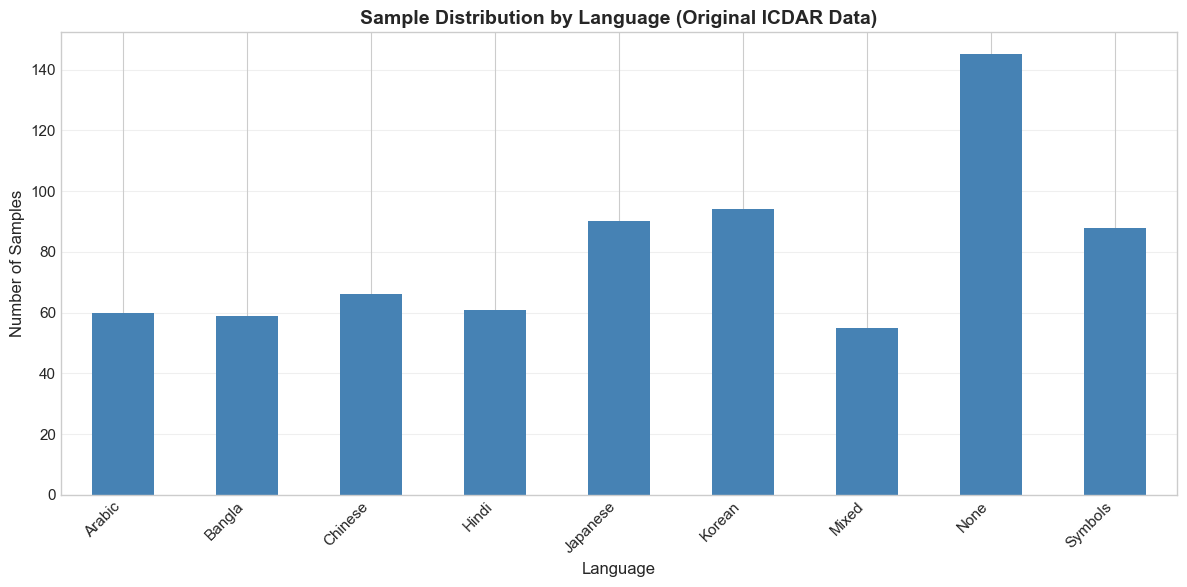

In [74]:
# Language breakdown using enhanced metadata from original ICDAR dataset
if enhanced_metadata and 'languages_list' in df_pa.columns:
    # Use the enhanced metadata for accurate language counts
    all_languages = []
    for _, row in df_pa.iterrows():
        if pd.notna(row.get('languages_list')):
            # languages_list is stored as a string representation of list, need to eval it
            try:
                langs = eval(row['languages_list'])
                all_languages.extend(langs)
            except:
                # Fallback to original processing if eval fails
                lang_str = str(row.get('language', ''))
                if lang_str:
                    langs = split_languages(lang_str)
                    all_languages.extend(langs)
    
    # Filter out 'latin' and create language counts
    lang_series = pd.Series(all_languages)
    lang_exploded = lang_series[lang_series.str.lower() != 'latin']
    lang_exploded = lang_exploded[lang_exploded.notna() & (lang_exploded != '')]
    language_counts = lang_exploded.value_counts().sort_index()
    
    print("Language Distribution (from original ICDAR dataset, excluding 'latin'):")
    print(language_counts)
    print(f"\nTotal unique languages: {len(language_counts)}")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    language_counts.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Sample Distribution by Language (Original ICDAR Data)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Language', fontsize=12)
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
elif 'language' in df_pa.columns:
    # Fallback to original processing if enhanced metadata not available
    lang_exploded = df_pa['language'].dropna().apply(split_languages).explode()
    lang_exploded = lang_exploded[lang_exploded.str.lower() != 'latin']
    lang_exploded = lang_exploded[lang_exploded.notna() & (lang_exploded != '')]
    language_counts = lang_exploded.value_counts().sort_index()
    print("Language Distribution (grouped by unique language, excluding 'latin' and None):")
    print(language_counts)
    print(f"\nTotal unique languages: {len(language_counts)}")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    language_counts.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Sample Distribution by Language', fontsize=14, fontweight='bold')
    ax.set_xlabel('Language', fontsize=12)
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Warning: No language data available in dataset")

## Basic Statistics

### Enhanced Language Analysis

Using additional metadata from the original ICDAR dataset for better language classification and analysis.

In [75]:
# Model definitions
models_pa = ['azure_intelligence', 'mistral_document_ai']
models_pb = ['gpt-5-mini', 'gpt-5-nano']
models_pc = ['gpt-5-mini', 'gpt-5-nano']

all_models = models_pa + models_pb + models_pc

print("Phase A (OCR models):", models_pa)
print("Phase B (VLM baseline):", models_pb)
print("Phase C (VLM + context):", models_pc)

# Ground truth statistics - ensure ground_truth is string type
if 'ground_truth' in df_pa.columns:
    gt_lengths = df_pa['ground_truth'].astype(str).str.len()
    print("\nGround Truth Text Statistics:")
    print(f"  Mean length: {gt_lengths.mean():.1f} characters")
    print(f"  Median length: {gt_lengths.median():.1f} characters")
    print(f"  Min length: {gt_lengths.min()} characters")
    print(f"  Max length: {gt_lengths.max()} characters")

Phase A (OCR models): ['azure_intelligence', 'mistral_document_ai']
Phase B (VLM baseline): ['gpt-5-mini', 'gpt-5-nano']
Phase C (VLM + context): ['gpt-5-mini', 'gpt-5-nano']

Ground Truth Text Statistics:
  Mean length: 257.5 characters
  Median length: 60.0 characters
  Min length: 1 characters
  Max length: 24368 characters


In [76]:
# Statistics tables: models as rows, phases as columns
import pandas as pd
from IPython.display import display
import ipywidgets as widgets

# Check if df_results has been created
if 'df_results' not in globals():
    print("⚠️  ERROR: df_results not yet created!")
    print("   Please run the 'Calculate metrics for all phases and models' cell first")
    print("   to compute metrics before displaying statistics.")
else:
    # First, merge ground_truth into df_results if not present
    if 'ground_truth' not in df_results.columns:
        # Merge with original dataframes to get ground_truth
        df_all = pd.concat([df_pa[['sample_id', 'ground_truth']], df_pb[['sample_id', 'ground_truth']], df_pc[['sample_id', 'ground_truth']]], ignore_index=True).drop_duplicates()
        df_results = df_results.merge(df_all, on='sample_id', how='left')

    # Find the correct column for ground truth text
    possible_gt_cols = [col for col in df_results.columns if 'ground' in col and 'truth' in col]
    if possible_gt_cols:
        gt_col = possible_gt_cols[0]
    else:
        raise KeyError("No column containing ground truth text found in df_results.")

    # 1. Average number of characters (total)
    df_results['gt_length'] = df_results[gt_col].astype(str).str.len()
    avg_chars_total = df_results.pivot_table(index='model', columns='phase', values='gt_length', aggfunc='mean')
    print('Average Number of Characters (Total)')
    display(avg_chars_total.round(2))

    # 2. Average CER per unique language (one table per unique language, paged viewer)
    if 'language' in df_results.columns:
        # Handle language combinations: explode if language is a list/string with delimiters
        import re
        def split_languages(lang_str):
            if pd.isna(lang_str):
                return []
            # Split on common delimiters: comma, semicolon, pipe, slash, whitespace
            return [l.strip() for l in re.split(r'[;,|/\s]+', str(lang_str)) if l.strip() and l.strip().lower() != 'latin']
        
        # Explode the language column to have one row per language per sample
        df_exploded = df_results.copy()
        df_exploded['language_list'] = df_exploded['language'].apply(split_languages)
        df_exploded = df_exploded.explode('language_list').dropna(subset=['language_list'])
        df_exploded = df_exploded[df_exploded['language_list'] != '']
        
        # Get unique languages from exploded
        unique_langs = sorted(df_exploded['language_list'].unique())[:10]  # Limit to 10 languages
        
        def show_table(lang):
            lang_df = df_exploded[df_exploded['language_list'] == lang]
            avg_cer_lang = lang_df.pivot_table(index='model', columns='phase', values='cer', aggfunc='mean')
            print(f'Average CER for Language: {lang}')
            display(avg_cer_lang.round(4))
        
        widgets.interact(show_table, lang=widgets.Dropdown(options=unique_langs, description='Language:'))
    else:
        print("No 'language' column found in df_results.")

    # 3. (Extra) Average CER, WER, ANLS, Cosine Similarity (for reference)
    for metric in ['cer', 'wer', 'anls', 'cosine_similarity']:
        avg_metric = df_results.pivot_table(index='model', columns='phase', values=metric, aggfunc='mean')
        print(f'Average {metric.upper()} by Model and Phase')
        display(avg_metric.round(4))

Average Number of Characters (Total)


phase,Pa,Pb,Pc
model,,,
azure_intelligence,3.0,NaN,NaN
gpt-5-mini,NaN,3.0,3.0
gpt-5-nano,NaN,3.0,3.0
mistral_document_ai,3.0,NaN,NaN


interactive(children=(Dropdown(description='Language:', options=('Arabic', 'Bangla', 'Chinese', 'Hindi', 'Japa…

Average CER by Model and Phase


phase,Pa,Pb,Pc
model,,,
azure_intelligence,5.5261,NaN,NaN
gpt-5-mini,NaN,2.1256,0.7336
gpt-5-nano,NaN,2.1256,0.7336
mistral_document_ai,5.5261,NaN,NaN


...

phase,Pa,Pb,Pc
model,,,
azure_intelligence,4.6697,NaN,NaN
gpt-5-mini,NaN,2.021,0.8544
gpt-5-nano,NaN,2.021,0.8544
mistral_document_ai,4.6697,NaN,NaN


Average ANLS by Model and Phase


phase,Pa,Pb,Pc
model,,,
azure_intelligence,0.0736,NaN,NaN
gpt-5-mini,NaN,0.1824,0.2228
gpt-5-nano,NaN,0.1824,0.2228
mistral_document_ai,0.0736,NaN,NaN


Average COSINE_SIMILARITY by Model and Phase


phase,Pa,Pb,Pc
model,,,
azure_intelligence,0.4547,NaN,NaN
gpt-5-mini,NaN,0.5589,0.4744
gpt-5-nano,NaN,0.5589,0.4744
mistral_document_ai,0.4547,NaN,NaN


### Sample Predictions

In [80]:
# Display 10 random samples with metrics
import random

# Get 10 random samples from df_results
random_samples = df_results.sample(n=min(10, len(df_results)), random_state=random.randint(0, 10000))

for sample_num, (_, row) in enumerate(random_samples.iterrows(), 1):
    # Get the metrics from the row
    cer_score = row['cer']
    wer_score = row['wer']
    cosine_sim_score = row['cosine_similarity']
    anls_score = row['anls']
    
    # Get the sample data
    sample_id = row['sample_id']
    phase = row['phase']
    model = row['model']
    
    # Get the phase dataframe
    phase_df = phase_dfs.get(phase)
    if phase_df is None:
        continue
    
    # Find the sample in the phase dataframe
    sample_row = phase_df[phase_df['sample_id'] == sample_id]
    if len(sample_row) == 0:
        continue
    
    sample_row = sample_row.iloc[0]
    
    # Get prediction and ground truth
    pred_col = f'prediction_{model}'
    prediction = sample_row.get(pred_col, 'N/A')
    ground_truth = sample_row.get('ground_truth', 'N/A')
    
    # Format and print
    print(f"Sample {sample_num}: CER: {cer_score:.4f}, WER: {wer_score:.4f}, Cosine Similarity: {cosine_sim_score:.4f}, ANLS: {anls_score:.4f}")
    print(f"Model: {model} | Phase: {phase}")
    print(f"Prediction: {prediction}")
    print(f"Ground truth: {ground_truth}")
    print()


Sample 1: CER: 0.3684, WER: 0.5000, Cosine Similarity: 0.9393, ANLS: 0.6316
Model: gpt-5-nano | Phase: Pc
Prediction: 康体中心
高尔夫球场接待站
太阳会所
嘉宾国际酒店
西餐厅、KTV
酒店公寓
Ground truth: 高尔夫球场接待站
康体中心
嘉宾国际酒店
太阳会所
西餐厅、KTV
酒店公寓

Sample 2: CER: 6.8966, WER: 12.2500, Cosine Similarity: 0.1868, ANLS: 0.0000
Model: azure_intelligence | Phase: Pa
Prediction: महानगरपालिका
बंगला
पुणे
खराडी
Ground truth: ID-100000
अन्य के लिए, इस पर निर्भरता के साथ, कोरोना वायरस के रूप जारी की गई । अन्य के लिए, इस पर निर्भरता के साथ, कोरोना वायरस के रूप जारी की गई । अन्य के लिए, इस पर निर्भरता के साथ, कोरोना वायरस के रूप जारी की गई ।

Sample 3: CER: 0.5000, WER: 0.6667, Cosine Similarity: 0.9013, ANLS: 0.5000
Model: gpt-5-nano | Phase: Pb
Prediction: পরীক্ষা
চক্ষু
চশমা
Ground truth: চক্ষু পরীক্ষা
চশমা

Sample 4: CER: 0.0633, WER: 0.2667, Cosine Similarity: 0.9636, ANLS: 0.9387
Model: azure_intelligence | Phase: Pa
Prediction: 中国驰名商标
长白山
R
世界三大天然优质水源之一
联合国人与生物圈自然保护区
泉阳泉
国际饮水组织示范水源
中国长白山矿泉水加工区
企业通过
ISO9001国际质量管理体系认证
ISO14001国际环境管

# 3. Results exploration

### Aggregate Metrics by Model

In [81]:
# Aggregate by model and phase
df_agg = df_results.groupby(['phase', 'model']).agg({
    'cer': ['mean', 'std', 'median'],
    'wer': ['mean', 'std', 'median'],
    'anls': ['mean', 'std', 'median'],
    'cosine_similarity': ['mean', 'std', 'median'],
    'sample_id': 'count',
    'valid_samples': 'first',
    'total_samples': 'first'
}).round(4)

df_agg.columns = ['_'.join(col).strip() for col in df_agg.columns.values]
df_agg = df_agg.rename(columns={
    'sample_id_count': 'n_samples',
    'valid_samples_first': 'valid_samples',
    'total_samples_first': 'total_samples'
})
df_agg = df_agg.reset_index()

print("Aggregated Metrics by Model and Phase:")
display(df_agg.sort_values(['phase', 'cer_mean']))

# Overall ranking (lower CER/WER is better, higher ANLS/cosine similarity is better)
df_overall = df_results.groupby('model').agg({
    'cer': 'mean',
    'wer': 'mean',
    'anls': 'mean',
    'cosine_similarity': 'mean',
    'sample_id': 'count'
}).round(4)

df_overall = df_overall.rename(columns={'sample_id': 'n_samples'})
df_overall = df_overall.sort_values('cer')

print("\nOverall Ranking (sorted by CER):")
display(df_overall)

# Show data quality summary
print("\n📊 Data Quality Summary:")
quality_summary = df_agg[['phase', 'model', 'valid_samples', 'total_samples']].copy()
quality_summary['Valid %'] = (quality_summary['valid_samples'] / quality_summary['total_samples'] * 100).round(1)
display(quality_summary)

Aggregated Metrics by Model and Phase:


,phase,model,cer_mean,cer_std,cer_median,wer_mean,wer_std,wer_median,anls_mean,anls_std,anls_median,cosine_similarity_mean,cosine_similarity_std,cosine_similarity_median,n_samples,valid_samples,total_samples
0,Pa,azure_intelligence,5.5261,36.5518,1.0823,4.6697,43.5491,1.0,0.0736,0.2162,0.0,0.4547,0.2841,0.4464,1272,491,491
1,Pa,mistral_document_ai,5.5261,36.5518,1.0823,4.6697,43.5491,1.0,0.0736,0.2162,0.0,0.4547,0.2841,0.4464,1272,491,491
2,Pb,gpt-5-mini,2.1256,7.7933,0.9459,2.0210,4.8588,1.0,0.1824,0.3278,0.0,0.5589,0.3404,0.6884,1272,491,491
3,Pb,gpt-5-nano,2.1256,7.7933,0.9459,2.0210,4.8588,1.0,0.1824,0.3278,0.0,0.5589,0.3404,0.6884,1272,491,491
4,Pc,gpt-5-mini,0.7336,0.4031,0.9429,0.8544,0.4253,1.0,0.2228,0.3619,0.0,0.4744,0.3604,0.4008,1272,491,491
5,Pc,gpt-5-nano,0.7336,0.4031,0.9429,0.8544,0.4253,1.0,0.2228,0.3619,0.0,0.4744,0.3604,0.4008,1272,491,491



Overall Ranking (sorted by CER):


,cer,wer,anls,cosine_similarity,n_samples
model,,,,,
gpt-5-mini,1.4296,1.4377,0.2026,0.5167,2544
gpt-5-nano,1.4296,1.4377,0.2026,0.5167,2544
azure_intelligence,5.5261,4.6697,0.0736,0.4547,1272
mistral_document_ai,5.5261,4.6697,0.0736,0.4547,1272



📊 Data Quality Summary:


,phase,model,valid_samples,total_samples,Valid %
0,Pa,azure_intelligence,491,491,100.0
1,Pa,mistral_document_ai,491,491,100.0
2,Pb,gpt-5-mini,491,491,100.0
3,Pb,gpt-5-nano,491,491,100.0
4,Pc,gpt-5-mini,491,491,100.0
5,Pc,gpt-5-nano,491,491,100.0


## 4. Overall View

Combined visualizations comparing all metrics across all models.

### Bar Charts - Average Metrics by Model

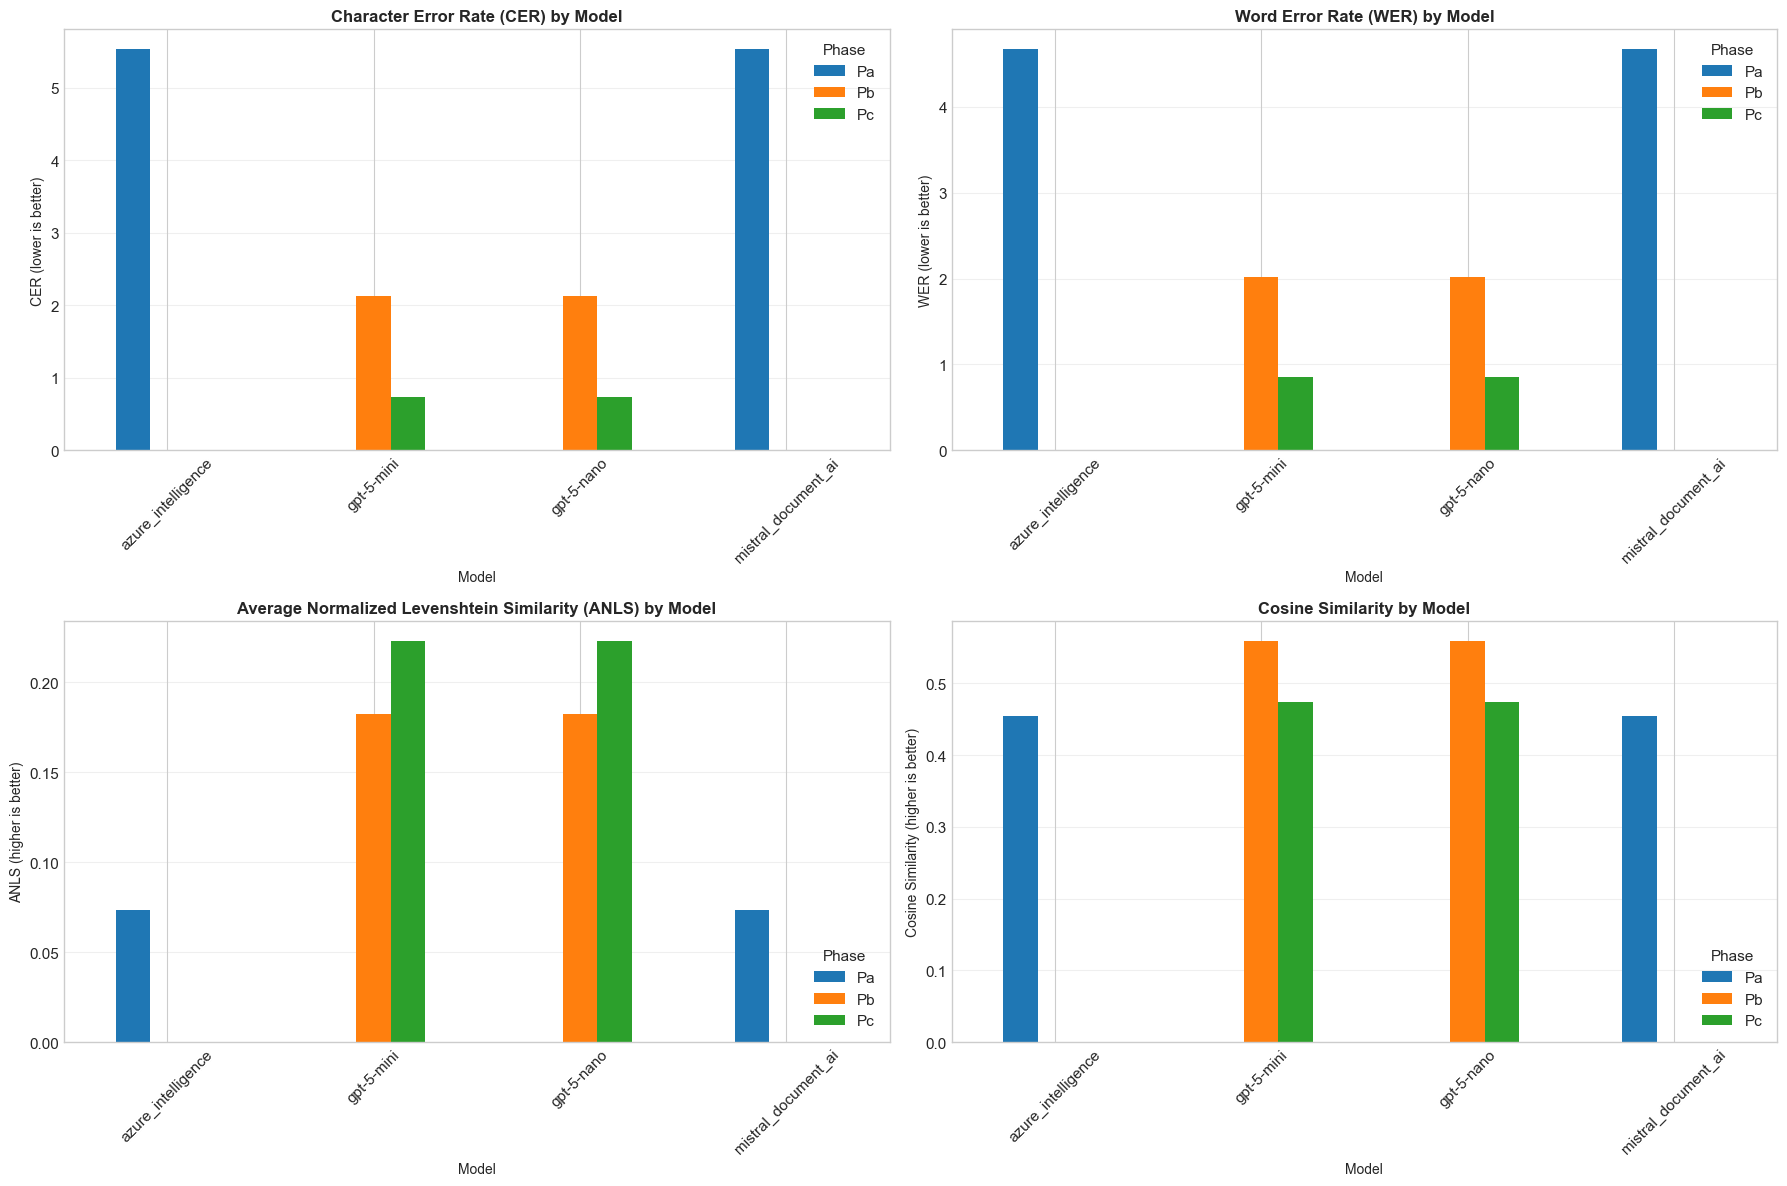

In [82]:
# Create bar charts for each metric
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# CER
df_pivot_cer = df_results.groupby(['phase', 'model'])['cer'].mean().reset_index()
df_pivot_cer_wide = df_pivot_cer.pivot(index='model', columns='phase', values='cer')
df_pivot_cer_wide.plot(kind='bar', ax=axes[0, 0], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_title('Character Error Rate (CER) by Model', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Model', fontsize=10)
axes[0, 0].set_ylabel('CER (lower is better)', fontsize=10)
axes[0, 0].legend(title='Phase', loc='upper right')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# WER
df_pivot_wer = df_results.groupby(['phase', 'model'])['wer'].mean().reset_index()
df_pivot_wer_wide = df_pivot_wer.pivot(index='model', columns='phase', values='wer')
df_pivot_wer_wide.plot(kind='bar', ax=axes[0, 1], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 1].set_title('Word Error Rate (WER) by Model', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Model', fontsize=10)
axes[0, 1].set_ylabel('WER (lower is better)', fontsize=10)
axes[0, 1].legend(title='Phase', loc='upper right')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# ANLS
df_pivot_anls = df_results.groupby(['phase', 'model'])['anls'].mean().reset_index()
df_pivot_anls_wide = df_pivot_anls.pivot(index='model', columns='phase', values='anls')
df_pivot_anls_wide.plot(kind='bar', ax=axes[1, 0], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_title('Average Normalized Levenshtein Similarity (ANLS) by Model', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Model', fontsize=10)
axes[1, 0].set_ylabel('ANLS (higher is better)', fontsize=10)
axes[1, 0].legend(title='Phase', loc='lower right')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Cosine Similarity
df_pivot_cos = df_results.groupby(['phase', 'model'])['cosine_similarity'].mean().reset_index()
df_pivot_cos_wide = df_pivot_cos.pivot(index='model', columns='phase', values='cosine_similarity')
df_pivot_cos_wide.plot(kind='bar', ax=axes[1, 1], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 1].set_title('Cosine Similarity by Model', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Model', fontsize=10)
axes[1, 1].set_ylabel('Cosine Similarity (higher is better)', fontsize=10)
axes[1, 1].legend(title='Phase', loc='lower right')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

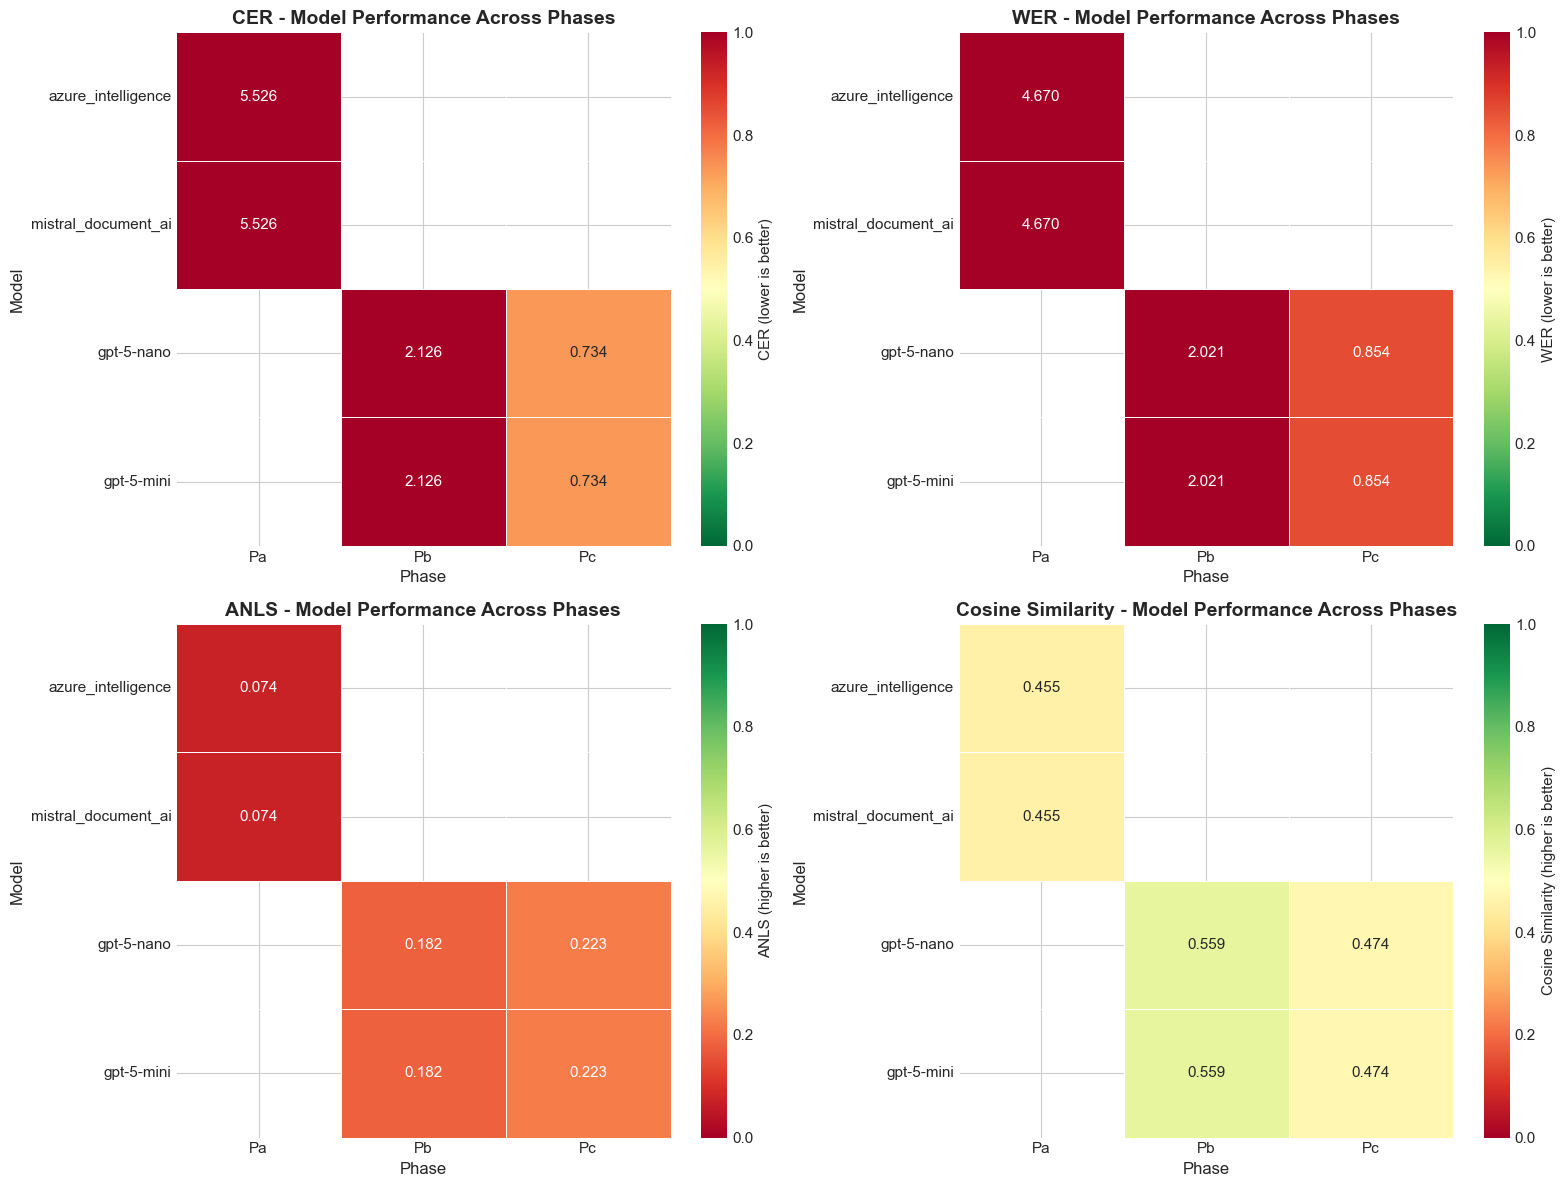

In [93]:
# Create heatmaps for each metric
metrics_to_show = [('CER', 'cer'), ('WER', 'wer'), ('ANLS', 'anls'), ('Cosine Similarity', 'cosine_similarity')]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (metric_name, metric_col) in enumerate(metrics_to_show):
    ax = axes[idx]
    
    # Create pivot table: rows = models, columns = phases
    pivot_data = df_results.pivot_table(
        index='model',
        columns='phase',
        values=metric_col,
        aggfunc='mean'
    )
    
    # Sort models according to MODEL_ORDER
    pivot_data = pivot_data.reindex(sort_models(pivot_data.index.tolist()))
    
    # Set colormap and label based on metric type
    if metric_name in ['CER', 'WER']:
        # Lower is better for error rates - use reversed colormap (green for low, red for high)
        cmap = 'RdYlGn_r'
        cbar_label = f'{metric_name} (lower is better)'
    else:
        # Higher is better for ANLS and Cosine Similarity - use normal colormap (green for high, red for low)
        cmap = 'RdYlGn'
        cbar_label = f'{metric_name} (higher is better)'
    
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5)
    
    ax.set_title(f'{metric_name} - Model Performance Across Phases', fontsize=14, fontweight='bold')
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()


# 5. Language-Specific Analysis

Analyze model performance broken down by language.

### Cosine Similiary - per Language - Boxplots

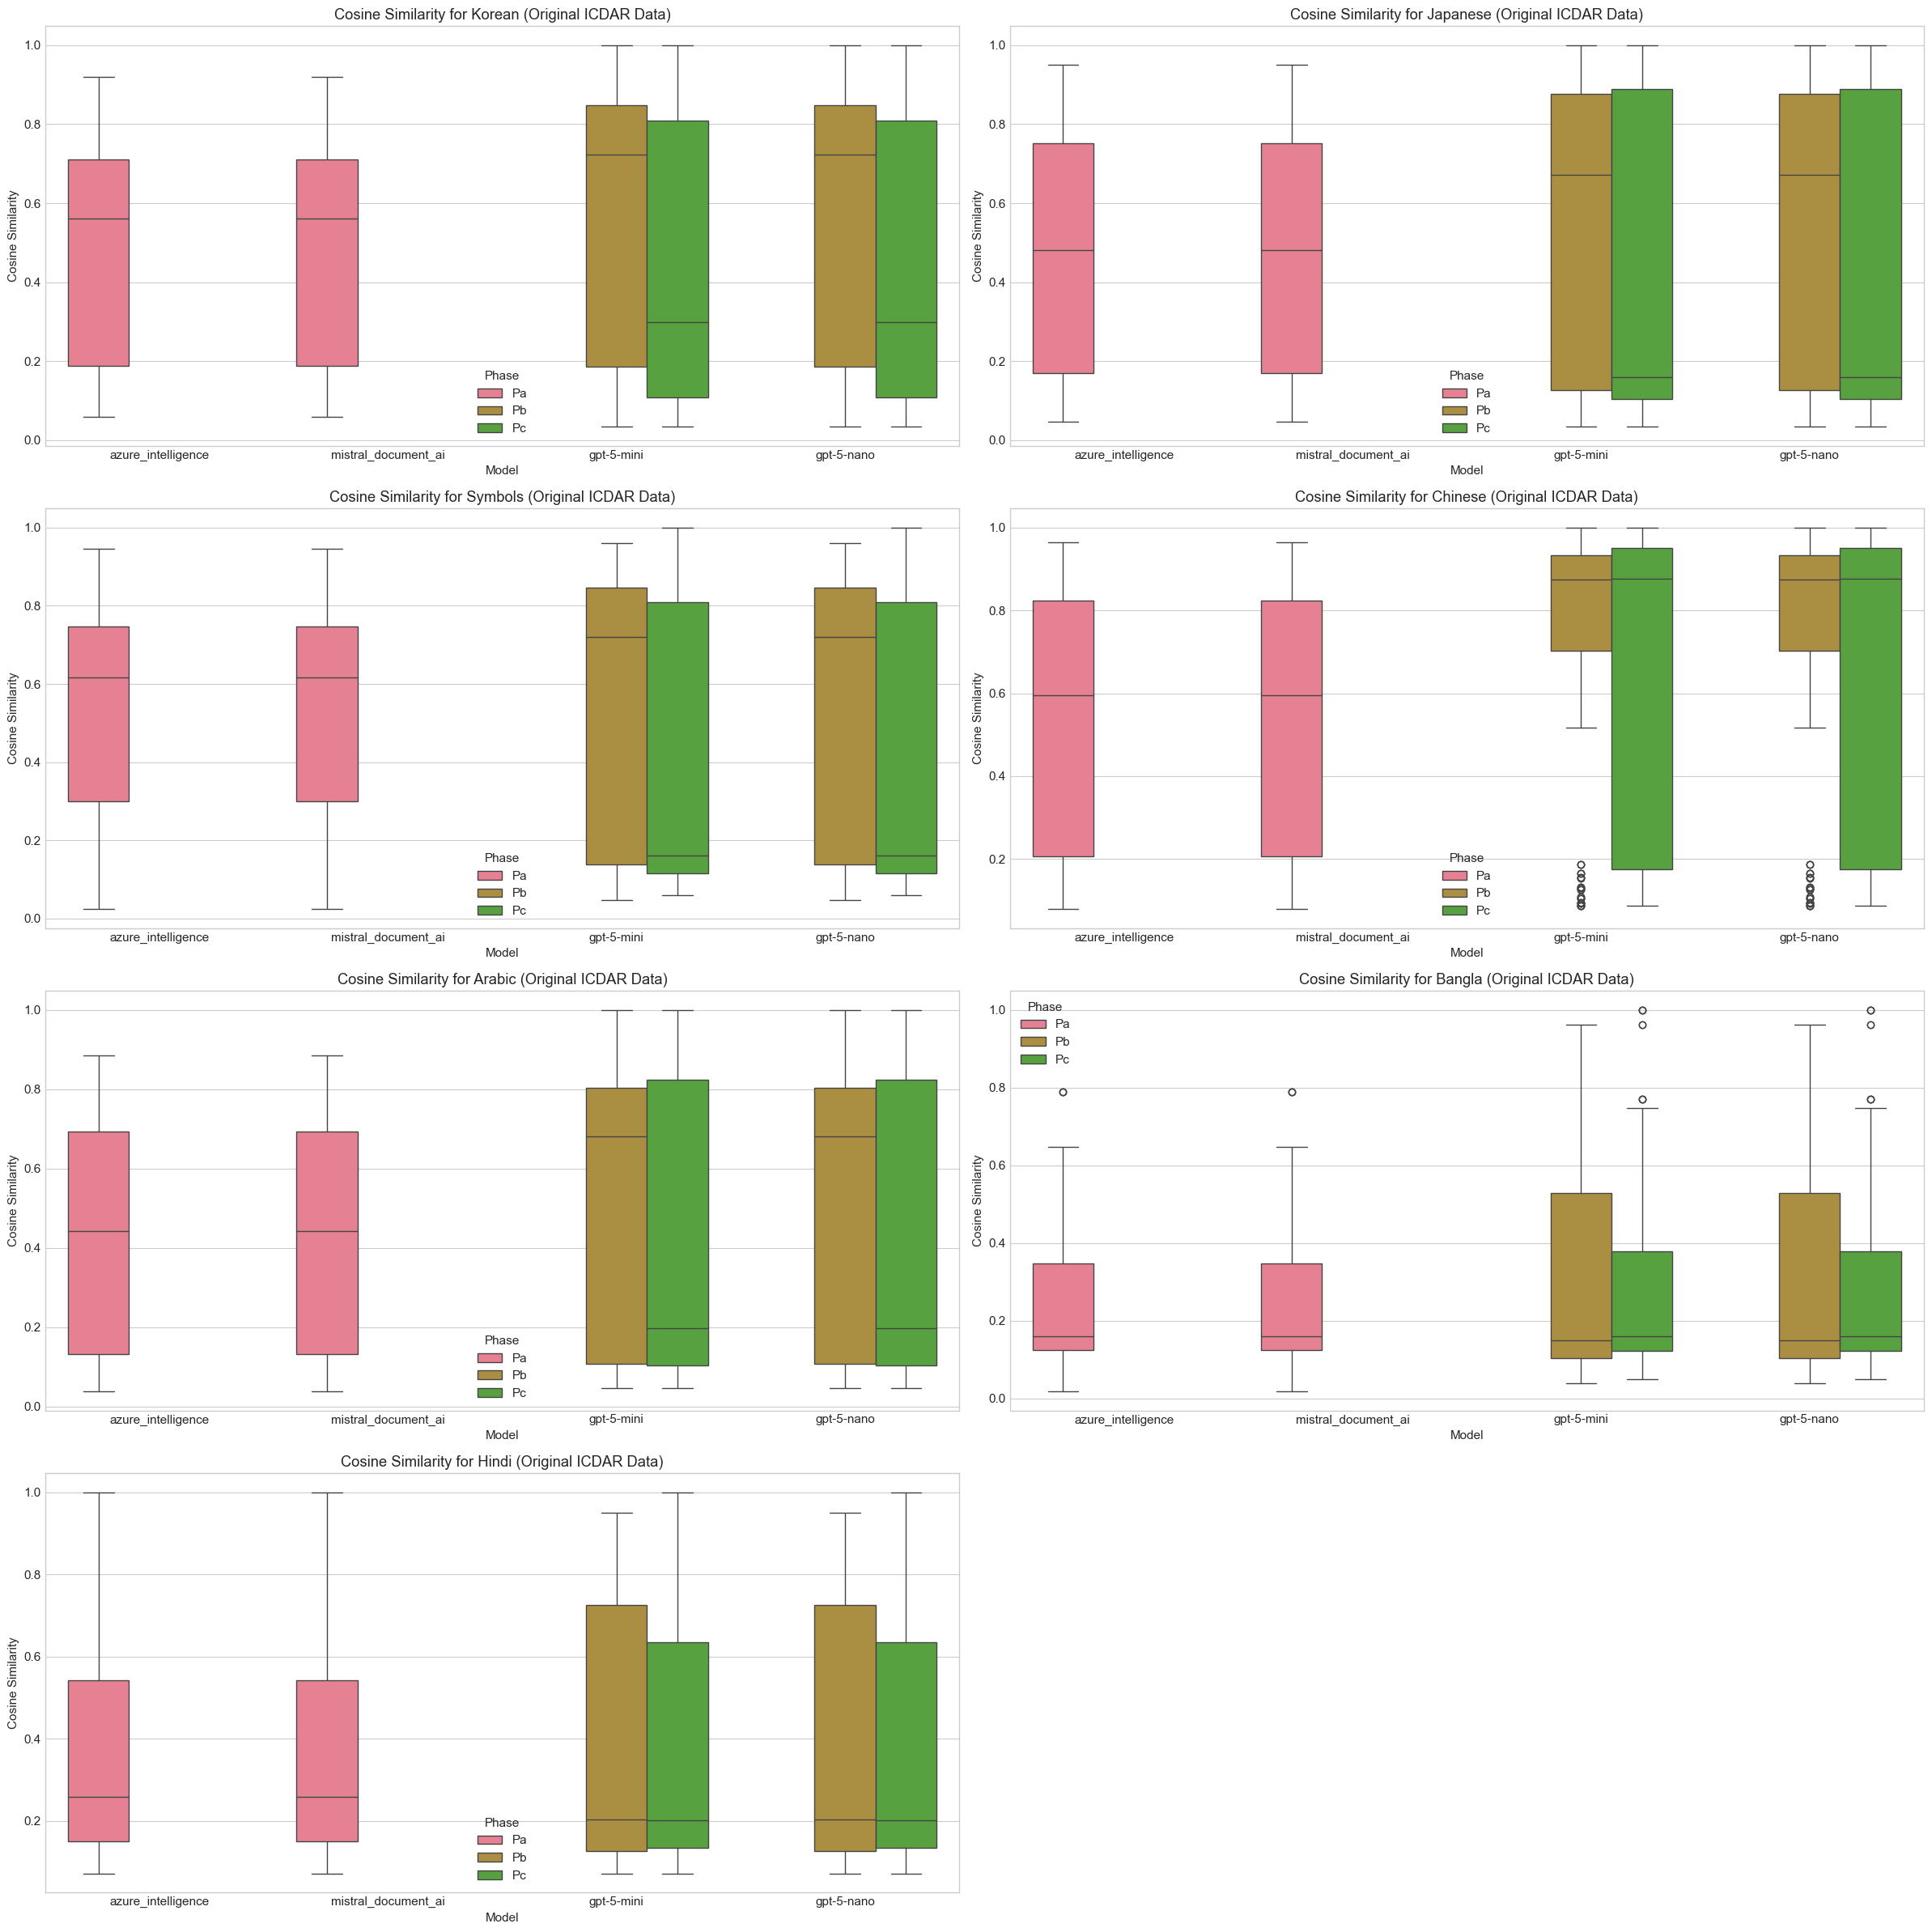

In [83]:
# Boxplot of Cosine Similarity by model and phase, per unique language (using original ICDAR language data)
import matplotlib.pyplot as plt
import seaborn as sns

if 'language' in df_results.columns:
    # Use the enhanced language data from df_results (already processed from original ICDAR)
    df_exploded = df_results.copy()
    
    # Since df_results.language now contains the accurate language strings from enhanced metadata,
    # we can split them reliably
    df_exploded['language_list'] = df_exploded['language'].apply(split_languages)
    df_exploded = df_exploded.explode('language_list').dropna(subset=['language_list'])
    df_exploded = df_exploded[df_exploded['language_list'] != '']
    
    # Filter out unwanted languages
    df_exploded = df_exploded[~df_exploded['language_list'].str.lower().isin(['none', 'mixed', 'latin'])]
    df_exploded = df_exploded[df_exploded['language_list'].str.match(r'^[A-Za-z]+$')]  # Only alphabetic languages
    
    # Get unique individual languages, sorted by frequency
    lang_counts = df_exploded['language_list'].value_counts()
    unique_langs = lang_counts.head(10).index.tolist()  # Top 10 most frequent languages
    
    if unique_langs:
        n_langs = len(unique_langs)
        rows = (n_langs + 1) // 2  # Two languages per row
        
        fig, axes = plt.subplots(rows, 2, figsize=(24, 6 * rows))
        if rows == 1:
            axes = [axes] if n_langs == 1 else axes
        else:
            axes = axes.flatten()
        
        for i, lang in enumerate(unique_langs):
            lang_df = df_exploded[df_exploded['language_list'] == lang]
            sns.boxplot(data=lang_df, x='model', y='cosine_similarity', hue='phase', ax=axes[i])
            axes[i].set_title(f'Cosine Similarity for {lang} (Original ICDAR Data)')
            axes[i].set_ylabel('Cosine Similarity')
            axes[i].set_xlabel('Model')
            axes[i].legend(title='Phase')
        
        # Hide unused subplots if odd number of languages
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid languages found after filtering.")
else:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_results, x='model', y='cosine_similarity', hue='phase')
    plt.title('Cosine Similarity by Model and Phase (All Languages)')
    plt.ylabel('Cosine Similarity')
    plt.xlabel('Model')
    plt.legend(title='Phase')
    plt.show()


### WER - per Language - Boxplots

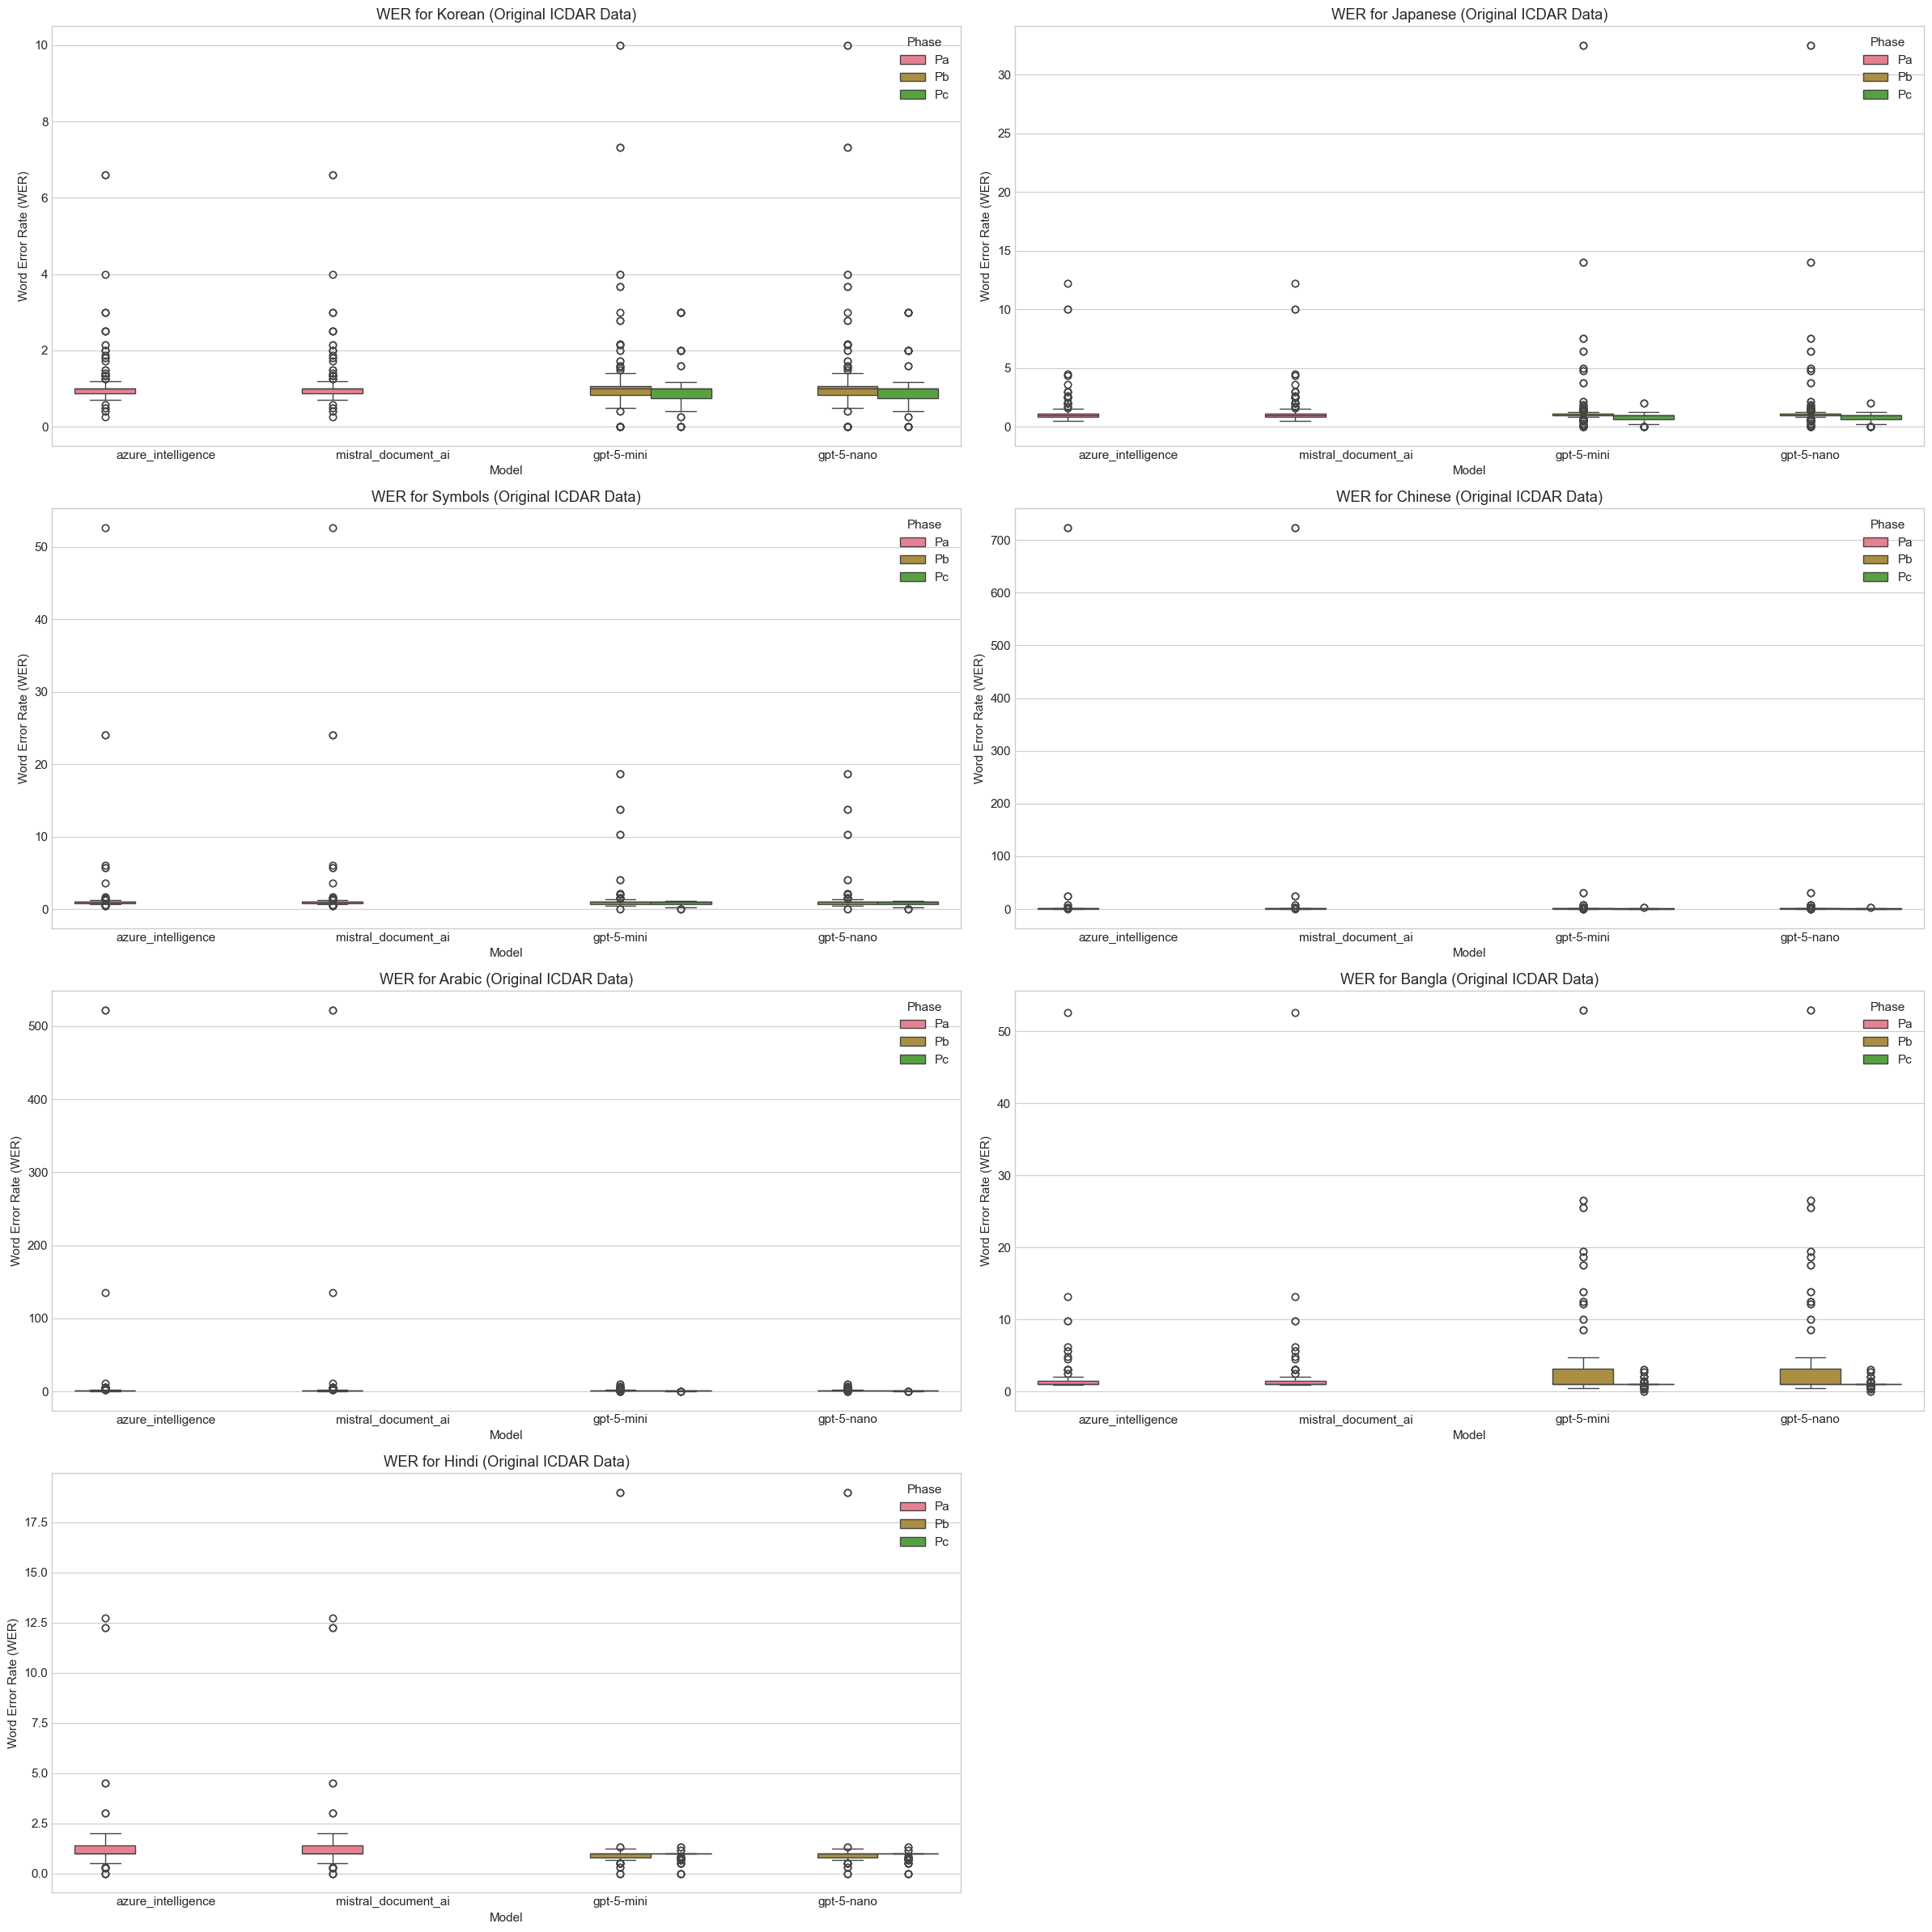

In [84]:
# Boxplot of WER by model and phase, per unique language (using original ICDAR language data)
import matplotlib.pyplot as plt
import seaborn as sns

if 'language' in df_results.columns:
    # Use the enhanced language data from df_results (already processed from original ICDAR)
    df_exploded = df_results.copy()
    
    # Since df_results.language now contains the accurate language strings from enhanced metadata,
    # we can split them reliably
    df_exploded['language_list'] = df_exploded['language'].apply(split_languages)
    df_exploded = df_exploded.explode('language_list').dropna(subset=['language_list'])
    df_exploded = df_exploded[df_exploded['language_list'] != '']
    
    # Filter out unwanted languages
    df_exploded = df_exploded[~df_exploded['language_list'].str.lower().isin(['none', 'mixed', 'latin'])]
    df_exploded = df_exploded[df_exploded['language_list'].str.match(r'^[A-Za-z]+$')]  # Only alphabetic languages
    
    # Get unique individual languages, sorted by frequency
    lang_counts = df_exploded['language_list'].value_counts()
    unique_langs = lang_counts.head(10).index.tolist()  # Top 10 most frequent languages
    
    if unique_langs:
        n_langs = len(unique_langs)
        rows = (n_langs + 1) // 2  # Two languages per row
        
        fig, axes = plt.subplots(rows, 2, figsize=(24, 6 * rows))
        if rows == 1:
            axes = [axes] if n_langs == 1 else axes
        else:
            axes = axes.flatten()
        
        for i, lang in enumerate(unique_langs):
            lang_df = df_exploded[df_exploded['language_list'] == lang]
            sns.boxplot(data=lang_df, x='model', y='wer', hue='phase', ax=axes[i])
            axes[i].set_title(f'WER for {lang} (Original ICDAR Data)')
            axes[i].set_ylabel('Word Error Rate (WER)')
            axes[i].set_xlabel('Model')
            axes[i].legend(title='Phase')
        
        # Hide unused subplots if odd number of languages
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid languages found after filtering.")
else:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_results, x='model', y='wer', hue='phase')
    plt.title('WER by Model and Phase (All Languages)')
    plt.ylabel('Word Error Rate (WER)')
    plt.xlabel('Model')
    plt.legend(title='Phase')
    plt.show()


### Scatter Plot: CER vs WER Correlation

### Error Analysis: Best and Worst Samples

### Inference Time Analysis

In [85]:
# Show 4 examples only when 'latin' is one of the languages in the row
from IPython.display import display

if 'language' in df_results.columns:
    # Filter for rows where 'latin' is in the language (handles both string and list cases)
    latin_rows = df_results[df_results['language'].apply(lambda x: 'latin' in x if isinstance(x, (list, set, tuple)) else ('latin' in str(x).lower()))]
    display(latin_rows.head(4))
else:
    print("No 'language' column found in df_results.")


,sample_id,phase,model,language,cer,wer,anls,cosine_similarity,ground_truth_in_prediction,valid_samples,total_samples,ground_truth,gt_length
0,icdar_tr_img_00008,Pa,azure_intelligence,"Latin, Arabic",1.206897,1.000000,0.0,0.082672,0.0,491,491,"<table><tr><td colspan=""3"">![img-0.jpeg](img-0.jpeg)</td></tr></table>",3
1,icdar_tr_img_00008,Pa,azure_intelligence,"Latin, Arabic",1.206897,1.000000,0.0,0.082672,0.0,491,491,- ولاية أريانة\n- BIENVENUE A L'ARIANA\n- WELCOME TO ARIANA,3
2,icdar_tr_img_00008,Pa,azure_intelligence,"Latin, Arabic",1.206897,1.000000,0.0,0.082672,0.0,491,491,NaN,3
3,icdar_tr_img_00019,Pa,azure_intelligence,"Symbols, Latin, Arabic",0.854015,0.772727,0.0,0.725690,0.0,491,491,# LABORATOIRE\n\n![img-0.jpeg](img-0.jpeg)\n\nEntreprise Chiheb Electrique\n\nEtude &amp; Câblag...,3


In [86]:
# Analyze best and worst performing samples for Phase A with language labels
if 'Pa' in phase_dfs:
    df_analysis = df_results[df_results['phase'] == 'Pa'].copy()
    
    # Get first model for analysis
    first_model = df_analysis['model'].iloc[0] if len(df_analysis) > 0 else None
    
    if first_model:
        # Get best and worst samples
        best_samples = df_analysis.nsmallest(5, 'cer')
        worst_samples = df_analysis.nlargest(5, 'cer')
        
        print("\n" + "="*120)
        print(f"BEST PERFORMING SAMPLES (Lowest CER) - Model: {first_model}")
        print("="*120)
        
        for _, row in best_samples.iterrows():
            sample_id = row['sample_id']
            sample_row = df_pa[df_pa['sample_id'] == sample_id].iloc[0] if len(df_pa[df_pa['sample_id'] == sample_id]) > 0 else None
            
            if sample_row is not None:
                language = row['language'] if 'language' in row else 'unknown'
                print(f"\nSample: {sample_id} | CER: {row['cer']:.4f} | Language: {language}")
                gt_text = str(sample_row['ground_truth'])
                print(f"=====\nGround Truth: {gt_text[:100]}..." if len(gt_text) > 100 else f"=====\nGround Truth: {gt_text}")
                
                pred_col = f'prediction_{first_model}'
                if pred_col in sample_row and pd.notna(sample_row[pred_col]):
                    pred_text = str(sample_row[pred_col])
                    print(f"----\nPrediction:   {pred_text[:100]}..." if len(pred_text) > 100 else f"----\nPrediction:   {pred_text}")
        
        print("\n" + "="*120)
        print(f"WORST PERFORMING SAMPLES (Highest CER) - Model: {first_model}")
        print("="*120)
        
        for _, row in worst_samples.iterrows():
            sample_id = row['sample_id']
            sample_row = df_pa[df_pa['sample_id'] == sample_id].iloc[0] if len(df_pa[df_pa['sample_id'] == sample_id]) > 0 else None
            
            if sample_row is not None:
                language = row['language'] if 'language' in row else 'unknown'
                print(f"\nSample: {sample_id} | CER: {row['cer']:.4f} | Language: {language}")
                gt_text = str(sample_row['ground_truth'])
                print(f"=====\nGround Truth: {gt_text[:100]}..." if len(gt_text) > 100 else f"=====\nGround Truth: {gt_text}")
                
                pred_col = f'prediction_{first_model}'
                if pred_col in sample_row and pd.notna(sample_row[pred_col]):
                    pred_text = str(sample_row[pred_col])
                    print(f"----\ngPrediction:   {pred_text[:100]}..." if len(pred_text) > 100 else f"----\nPrediction:   {pred_text}")


BEST PERFORMING SAMPLES (Lowest CER) - Model: azure_intelligence

Sample: icdar_tr_img_09607 | CER: 0.0000 | Language: Hindi
=====
Ground Truth: महालक्ष्मी
----
Prediction:   महालक्ष्मी

Sample: icdar_tr_img_09607 | CER: 0.0000 | Language: Hindi
=====
Ground Truth: महालक्ष्मी
----
Prediction:   महालक्ष्मी

Sample: icdar_tr_img_09607 | CER: 0.0000 | Language: Hindi
=====
Ground Truth: महालक्ष्मी
----
Prediction:   महालक्ष्मी

Sample: icdar_tr_img_09607 | CER: 0.0000 | Language: Hindi
=====
Ground Truth: महालक्ष्मी
----
Prediction:   महालक्ष्मी

Sample: icdar_tr_img_04690 | CER: 0.0556 | Language: Symbols, Latin
=====
Ground Truth: Achtung
Ausfahrt!
----
Prediction:   Achtung
Ausfahrt
!

WORST PERFORMING SAMPLES (Highest CER) - Model: azure_intelligence

Sample: icdar_tr_img_00708 | CER: 597.2857 | Language: Latin, Arabic
=====
Ground Truth: ![img-0.jpeg](img-0.jpeg)

# 2011

## 2011

### 2011

### 2011

### 2011

### 2011

### 2011

### 20...
----
Prediction:   NOOR
BANK
نور
بنك
بنك
نو

In [87]:
# Aggregate metrics by language and model
df_lang_perf = df_results.groupby(['language', 'model']).agg({
    'cer': 'mean',
    'wer': 'mean',
    'anls': 'mean',
    'cosine_similarity': 'mean',
    'sample_id': 'count'
}).round(4)

df_lang_perf = df_lang_perf.rename(columns={'sample_id': 'n_samples'})
df_lang_perf = df_lang_perf.reset_index()

print("Performance by Language and Model:")
display(df_lang_perf.sort_values(['language', 'cer']))

# Best model per language (by CER)
best_per_language = df_lang_perf.loc[df_lang_perf.groupby('language')['cer'].idxmin()]
display(best_per_language[['language', 'model', 'cer', 'wer', 'anls', 'cosine_similarity']])
display(best_per_language[['language', 'model', 'cer', 'wer', 'cosine_similarity']])

Performance by Language and Model:


,language,model,cer,wer,anls,cosine_similarity,n_samples
1,Arabic,gpt-5-mini,1.1468,1.4414,0.2339,0.4935,50
2,Arabic,gpt-5-nano,1.1468,1.4414,0.2339,0.4935,50
0,Arabic,azure_intelligence,2.2166,1.2409,0.2015,0.3486,25
3,Arabic,mistral_document_ai,2.2166,1.2409,0.2015,0.3486,25
5,Bangla,gpt-5-mini,3.3538,3.5870,0.0879,0.2798,136
...,...,...,...,...,...,...,...
254,"Symbols, Latin, Mixed",gpt-5-nano,0.9867,1.0000,0.0000,0.1459,4
257,"Symbols, Mixed, Korean, Latin, None",gpt-5-mini,0.9706,1.0000,0.0000,0.1179,4
258,"Symbols, Mixed, Korean, Latin, None",gpt-5-nano,0.9706,1.0000,0.0000,0.1179,4
256,"Symbols, Mixed, Korean, Latin, None",azure_intelligence,1.2059,0.8889,0.0000,0.6269,2


,language,model,cer,wer,anls,cosine_similarity
1,Arabic,gpt-5-mini,1.1468,1.4414,0.2339,0.4935
5,Bangla,gpt-5-mini,3.3538,3.5870,0.0879,0.2798
8,"Bangla, Latin",azure_intelligence,1.2043,1.3125,0.0750,0.3666
13,Chinese,gpt-5-mini,1.9289,1.8591,0.3905,0.6240
16,"Chinese, Japanese, Korean, Latin",azure_intelligence,0.8268,0.8667,0.0000,0.5958
...,...,...,...,...,...,...
240,"Symbols, Korean, Latin, Mixed",azure_intelligence,0.7532,0.8235,0.0000,0.7950
245,"Symbols, Latin",gpt-5-mini,0.5850,0.7275,0.2779,0.6809
249,"Symbols, Latin, Arabic",gpt-5-mini,0.8832,0.9204,0.0755,0.5500
252,"Symbols, Latin, Mixed",azure_intelligence,0.6711,0.8947,0.0000,0.8252


,language,model,cer,wer,cosine_similarity
1,Arabic,gpt-5-mini,1.1468,1.4414,0.4935
5,Bangla,gpt-5-mini,3.3538,3.5870,0.2798
8,"Bangla, Latin",azure_intelligence,1.2043,1.3125,0.3666
13,Chinese,gpt-5-mini,1.9289,1.8591,0.6240
16,"Chinese, Japanese, Korean, Latin",azure_intelligence,0.8268,0.8667,0.5958
...,...,...,...,...,...
240,"Symbols, Korean, Latin, Mixed",azure_intelligence,0.7532,0.8235,0.7950
245,"Symbols, Latin",gpt-5-mini,0.5850,0.7275,0.6809
249,"Symbols, Latin, Arabic",gpt-5-mini,0.8832,0.9204,0.5500
252,"Symbols, Latin, Mixed",azure_intelligence,0.6711,0.8947,0.8252


### Heatmap - CER by Language and Model

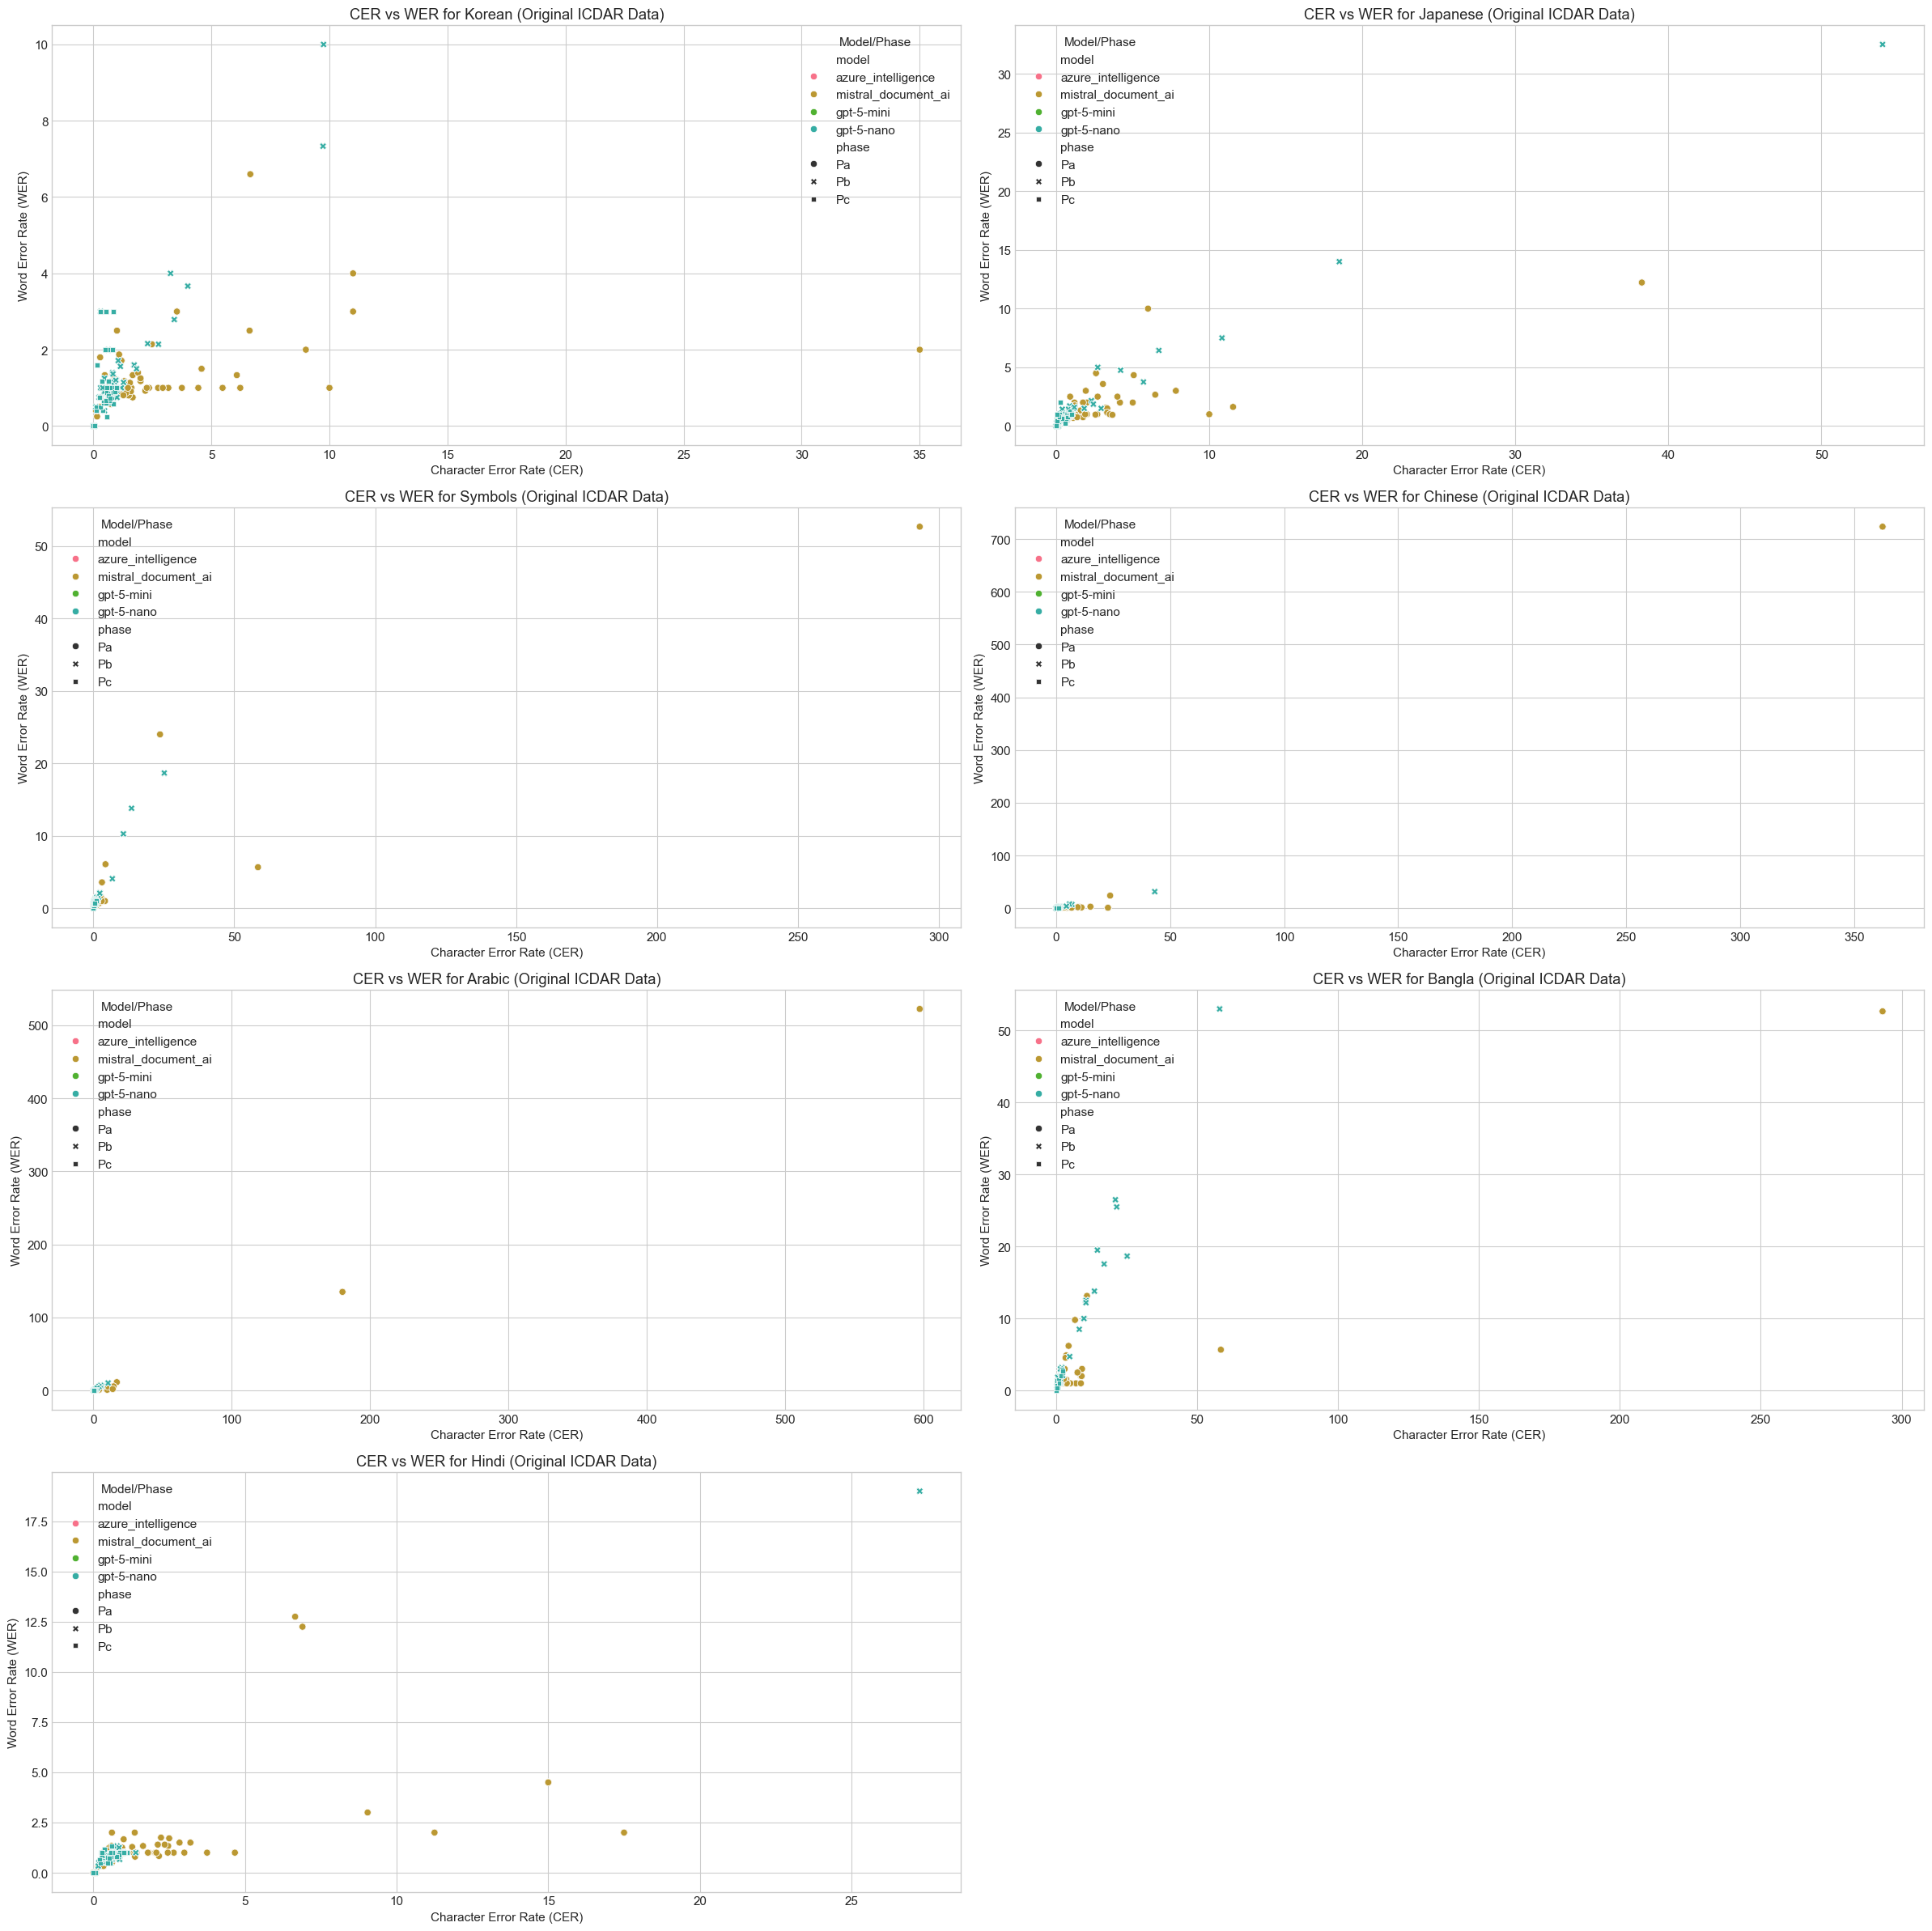

In [88]:
# Scatter plot of CER vs WER by model and phase, per unique language (using original ICDAR language data)
import matplotlib.pyplot as plt
import seaborn as sns

if 'language' in df_results.columns:
    # Use the enhanced language data from df_results (already processed from original ICDAR)
    df_exploded = df_results.copy()
    
    # Since df_results.language now contains the accurate language strings from enhanced metadata,
    # we can split them reliably
    df_exploded['language_list'] = df_exploded['language'].apply(split_languages)
    df_exploded = df_exploded.explode('language_list').dropna(subset=['language_list'])
    df_exploded = df_exploded[df_exploded['language_list'] != '']
    
    # Filter out unwanted languages
    df_exploded = df_exploded[~df_exploded['language_list'].str.lower().isin(['none', 'mixed', 'latin'])]
    df_exploded = df_exploded[df_exploded['language_list'].str.match(r'^[A-Za-z]+$')]  # Only alphabetic languages
    
    # Get unique individual languages, sorted by frequency
    lang_counts = df_exploded['language_list'].value_counts()
    unique_langs = lang_counts.head(10).index.tolist()  # Top 10 most frequent languages
    
    if unique_langs:
        n_langs = len(unique_langs)
        rows = (n_langs + 1) // 2  # Two languages per row
        
        fig, axes = plt.subplots(rows, 2, figsize=(24, 6 * rows))
        if rows == 1:
            axes = [axes] if n_langs == 1 else axes
        else:
            axes = axes.flatten()
        
        for i, lang in enumerate(unique_langs):
            lang_df = df_exploded[df_exploded['language_list'] == lang]
            sns.scatterplot(data=lang_df, x='cer', y='wer', hue='model', style='phase', ax=axes[i])
            axes[i].set_title(f'CER vs WER for {lang} (Original ICDAR Data)')
            axes[i].set_xlabel('Character Error Rate (CER)')
            axes[i].set_ylabel('Word Error Rate (WER)')
            axes[i].legend(title='Model/Phase')
        
        # Hide unused subplots if odd number of languages
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid languages found after filtering.")
else:
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df_results, x='cer', y='wer', hue='model', style='phase')
    plt.title('CER vs WER by Model and Phase (All Languages)')
    plt.xlabel('Character Error Rate (CER)')
    plt.ylabel('Word Error Rate (WER)')
    plt.legend(title='Model/Phase')
    plt.show()


### Language Difficulty Ranking

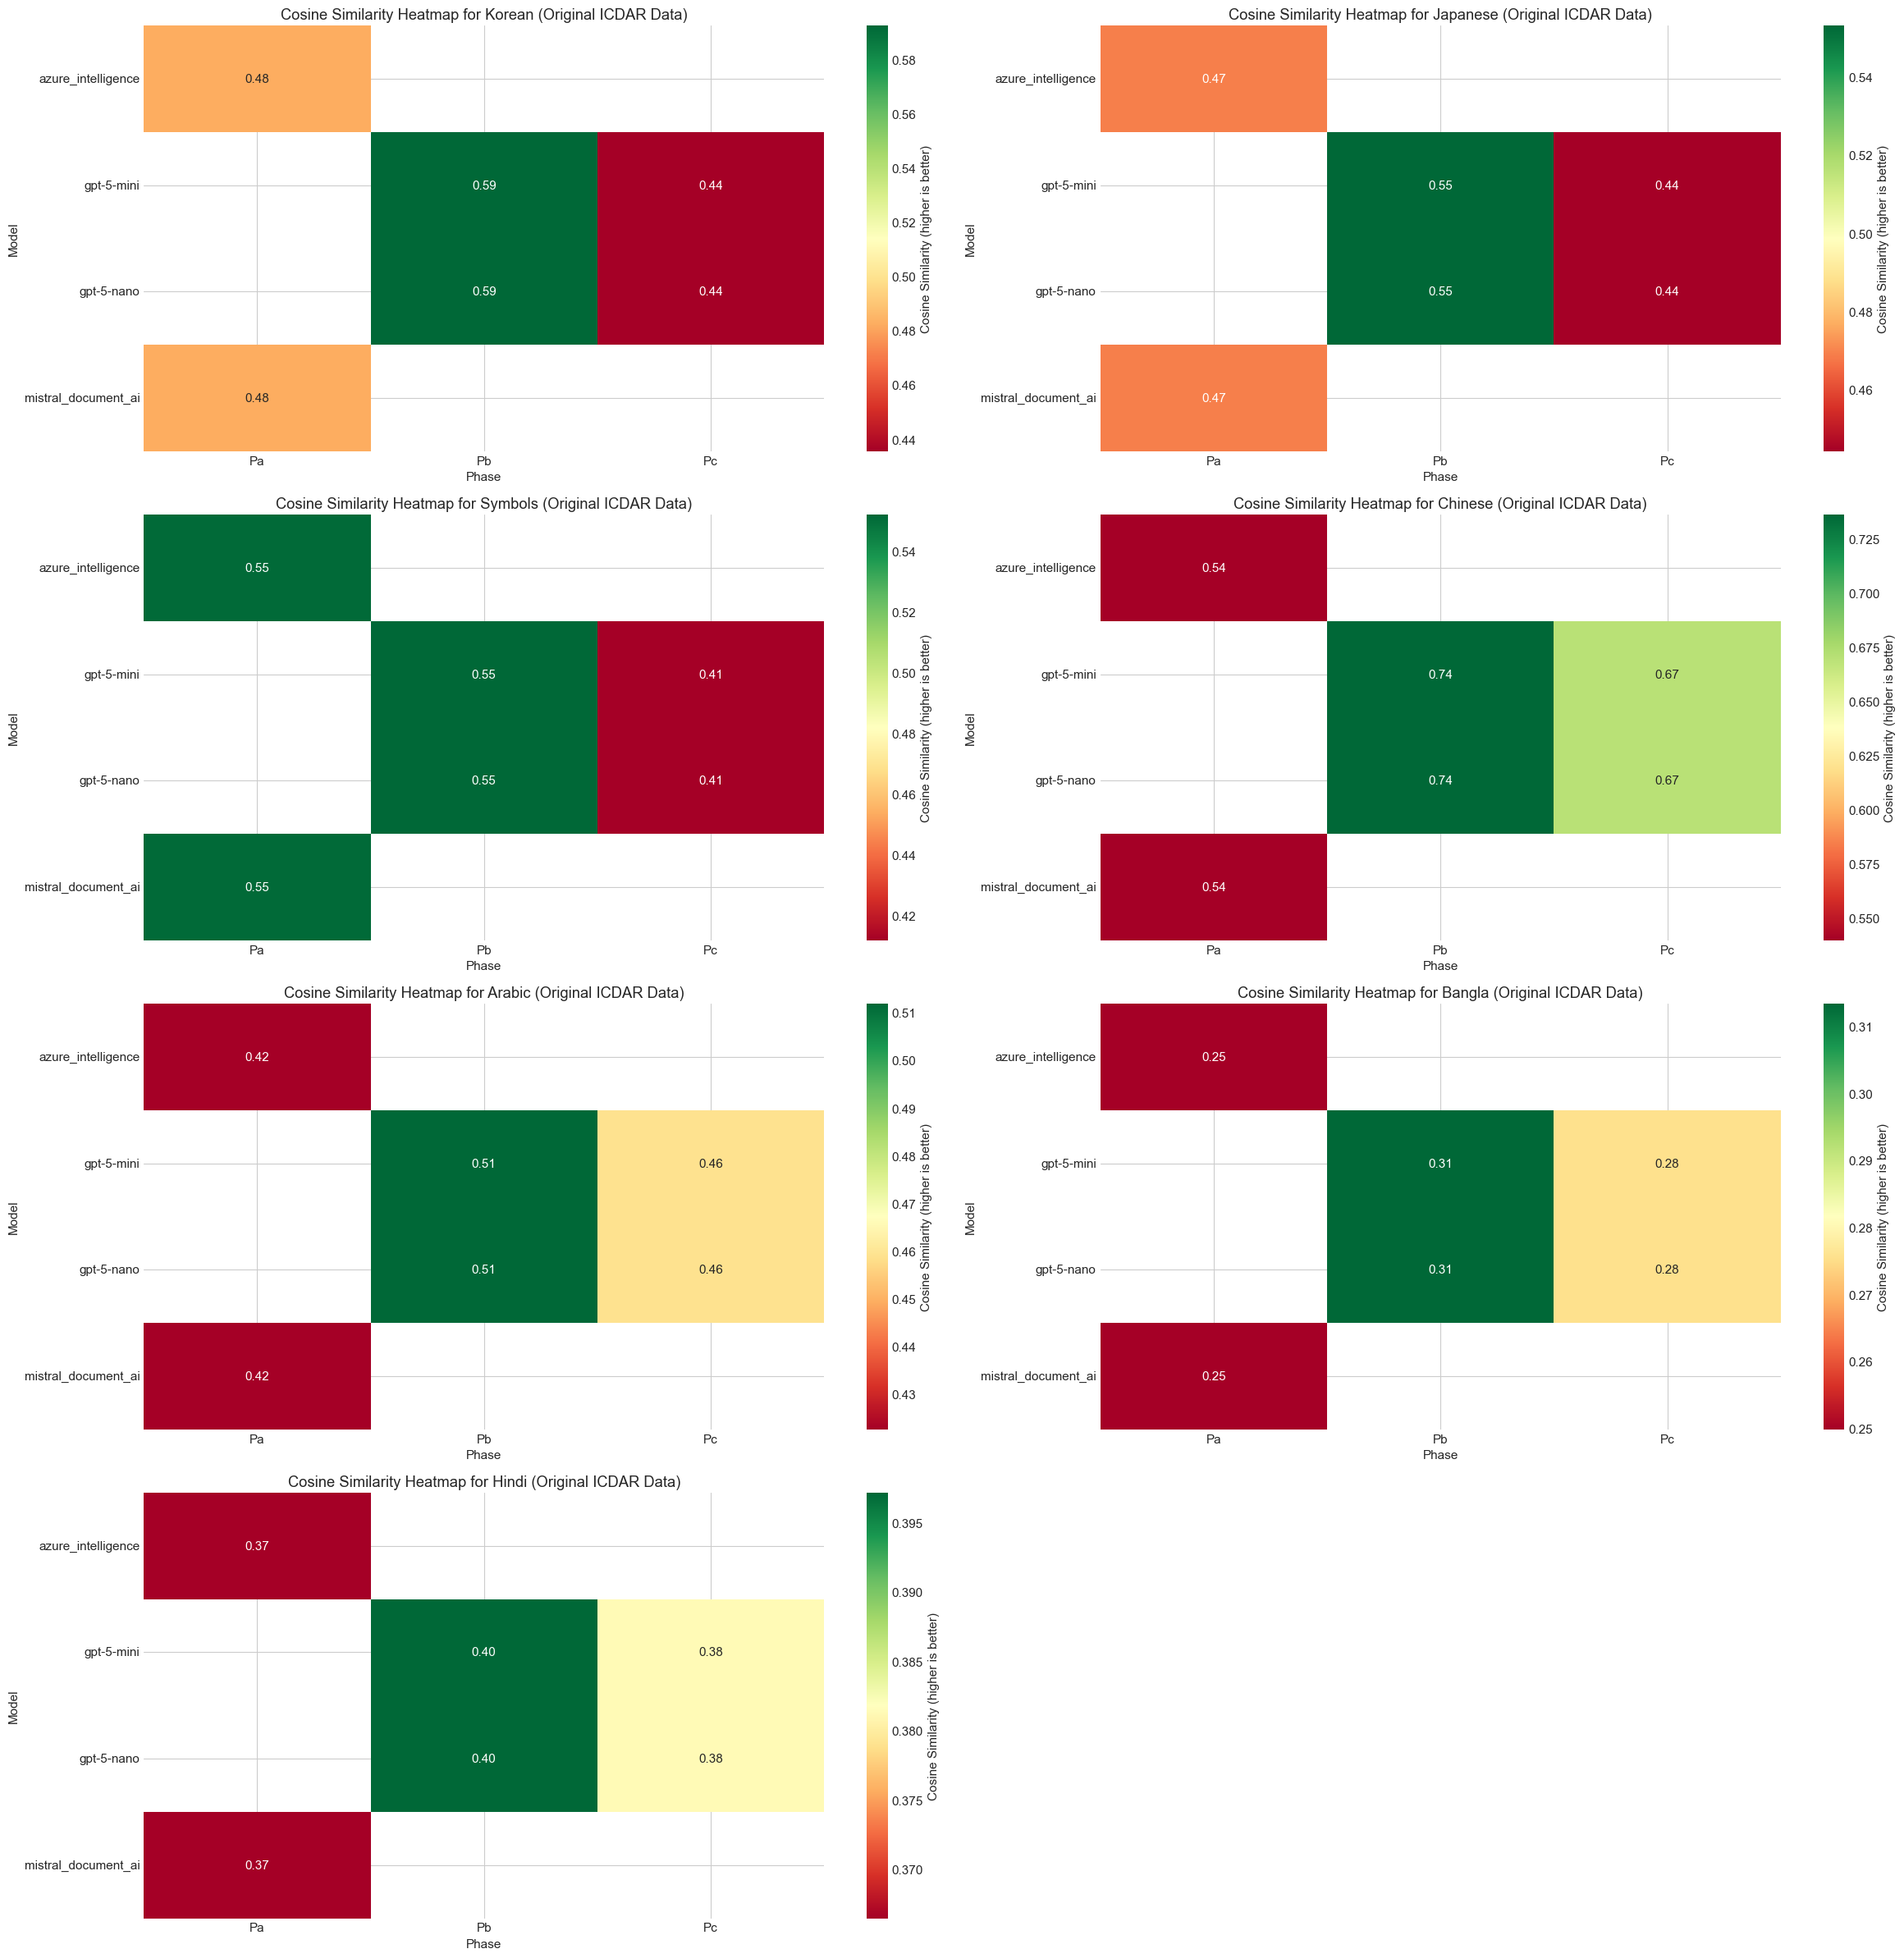

In [89]:
# Heatmap of Cosine Similarity by model and phase, per unique language (using original ICDAR language data)
import matplotlib.pyplot as plt
import seaborn as sns

if 'language' in df_results.columns:
    # Use the enhanced language data from df_results (already processed from original ICDAR)
    df_exploded = df_results.copy()
    
    # Since df_results.language now contains the accurate language strings from enhanced metadata,
    # we can split them reliably
    df_exploded['language_list'] = df_exploded['language'].apply(split_languages)
    df_exploded = df_exploded.explode('language_list').dropna(subset=['language_list'])
    df_exploded = df_exploded[df_exploded['language_list'] != '']
    
    # Filter out unwanted languages
    df_exploded = df_exploded[~df_exploded['language_list'].str.lower().isin(['none', 'mixed', 'latin'])]
    df_exploded = df_exploded[df_exploded['language_list'].str.match(r'^[A-Za-z]+$')]  # Only alphabetic languages
    
    # Get unique individual languages, sorted by frequency
    lang_counts = df_exploded['language_list'].value_counts()
    unique_langs = lang_counts.head(10).index.tolist()  # Top 10 most frequent languages
    
    if unique_langs:
        n_langs = len(unique_langs)
        rows = (n_langs + 1) // 2  # Two languages per row
        
        fig, axes = plt.subplots(rows, 2, figsize=(24, 6 * rows))
        if rows == 1:
            axes = [axes] if n_langs == 1 else axes
        else:
            axes = axes.flatten()
        
        for i, lang in enumerate(unique_langs):
            lang_df = df_exploded[df_exploded['language_list'] == lang]
            pivot = lang_df.pivot_table(index='model', columns='phase', values='cosine_similarity', aggfunc='mean')
            sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[i],
                       cbar_kws={'label': 'Cosine Similarity (higher is better)'})
            axes[i].set_title(f'Cosine Similarity Heatmap for {lang} (Original ICDAR Data)')
            axes[i].set_ylabel('Model')
            axes[i].set_xlabel('Phase')
        
        # Hide unused subplots if odd number of languages
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid languages found after filtering.")
else:
    pivot = df_results.pivot_table(index='model', columns='phase', values='cosine_similarity', aggfunc='mean')
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
               cbar_kws={'label': 'Cosine Similarity (higher is better)'})
    plt.title('Cosine Similarity Heatmap by Model and Phase (All Languages)')
    plt.ylabel('Model')
    plt.xlabel('Phase')
    plt.show()


### Language-Specific Cosine Similarity Analysis

ANLS and Cosine Similarity by Language, Model, and Phase:
Note: Texts >300 chars use chunked similarity (150-char chunks, 30-char overlap)


,language,model,phase,anls_mean,anls_std,cosine_similarity_mean,cosine_similarity_std,n_samples
0,Arabic,azure_intelligence,Pa,0.0463,0.1570,0.4225,0.2688,159
5,Arabic,mistral_document_ai,Pa,0.0463,0.1570,0.4225,0.2688,159
6,Bangla,azure_intelligence,Pa,0.0215,0.1079,0.2498,0.1806,154
11,Bangla,mistral_document_ai,Pa,0.0215,0.1079,0.2498,0.1806,154
12,Chinese,azure_intelligence,Pa,0.1336,0.2720,0.5398,0.3046,181
17,Chinese,mistral_document_ai,Pa,0.1336,0.2720,0.5398,0.3046,181
18,Hindi,azure_intelligence,Pa,0.1107,0.2694,0.3665,0.2628,152
23,Hindi,mistral_document_ai,Pa,0.1107,0.2694,0.3665,0.2628,152
24,Japanese,azure_intelligence,Pa,0.0669,0.2100,0.4690,0.2883,228
29,Japanese,mistral_document_ai,Pa,0.0669,0.2100,0.4690,0.2883,228



PHASE Pa VISUALIZATIONS



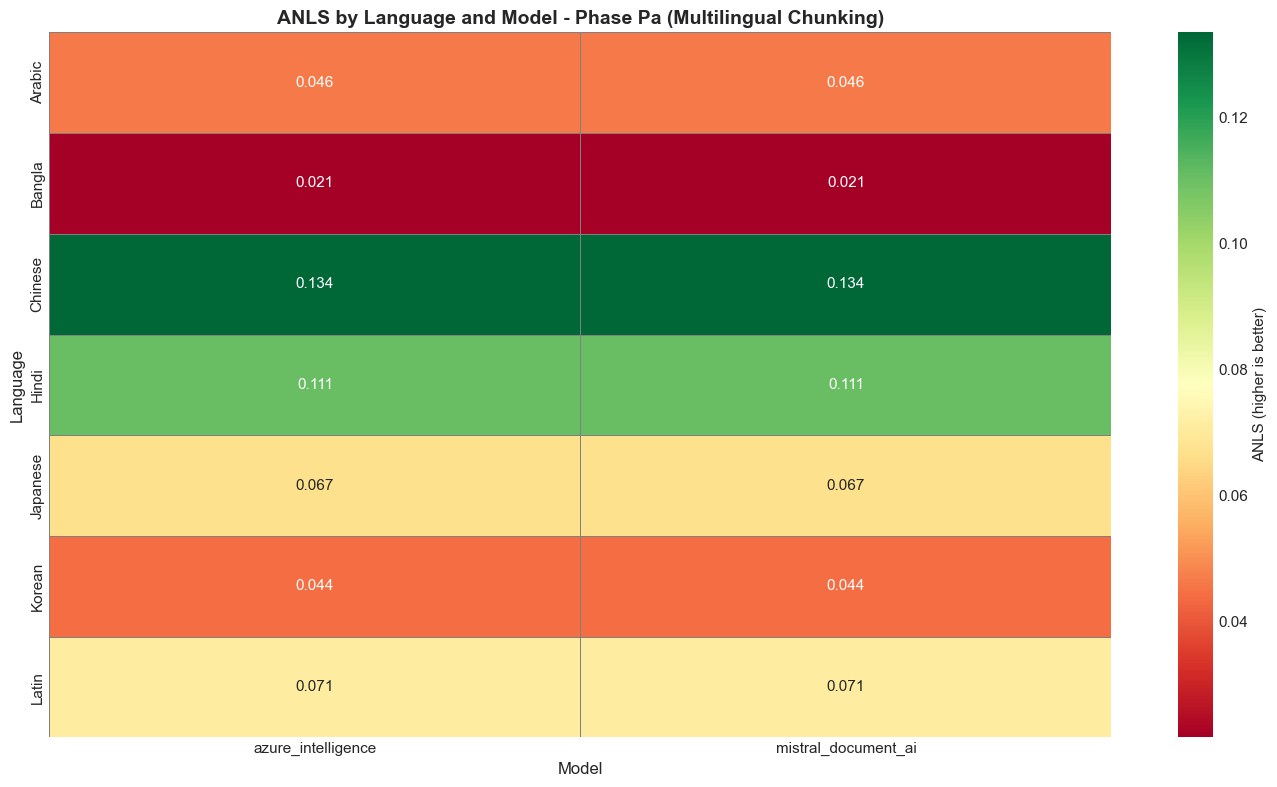

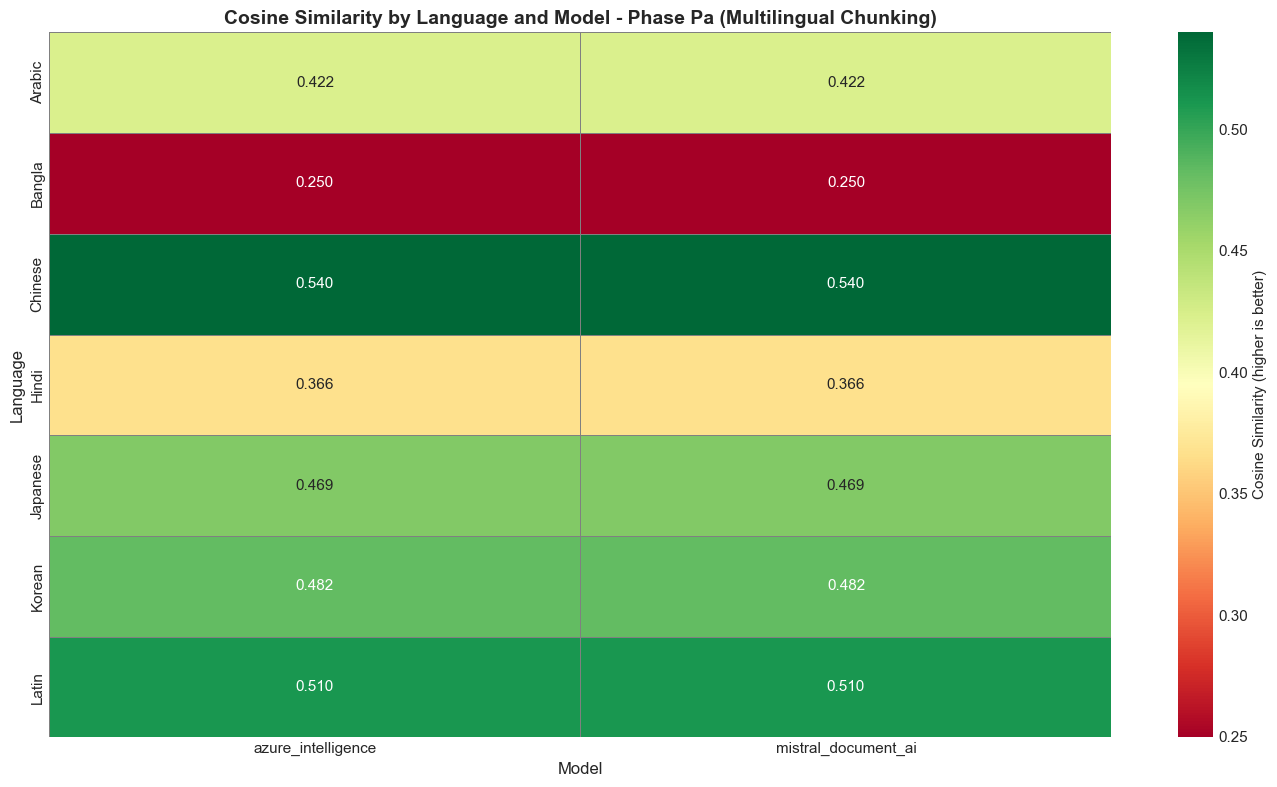

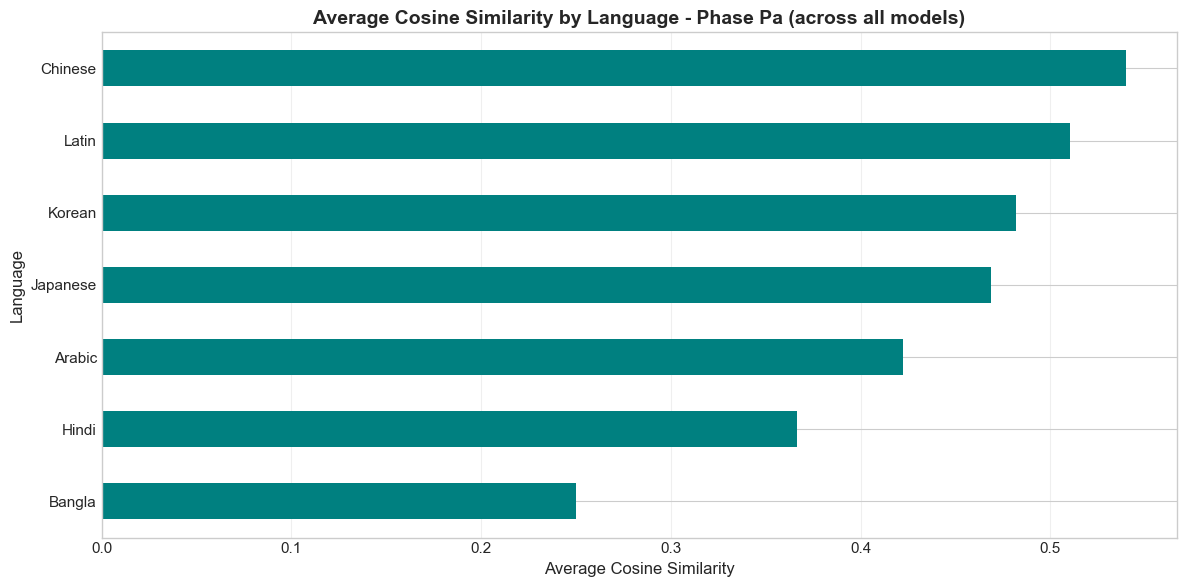


PHASE Pb VISUALIZATIONS



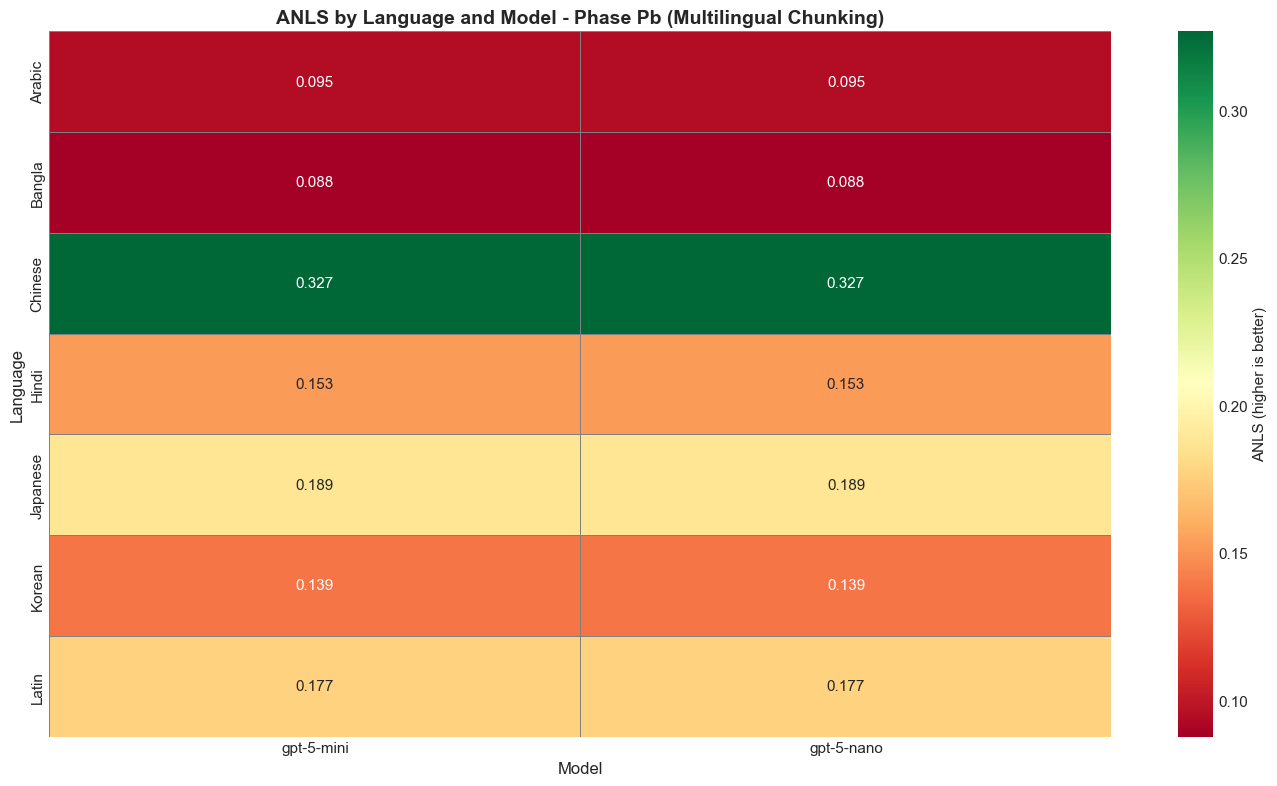

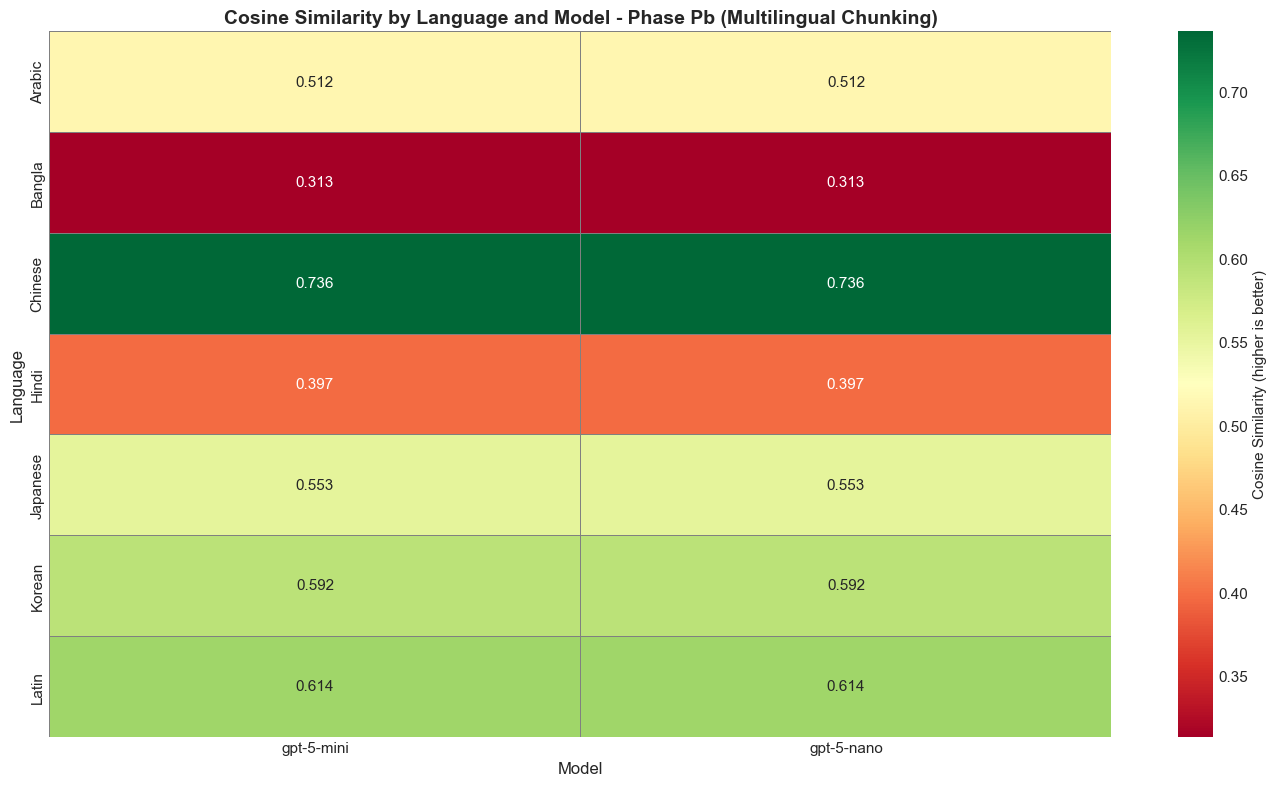

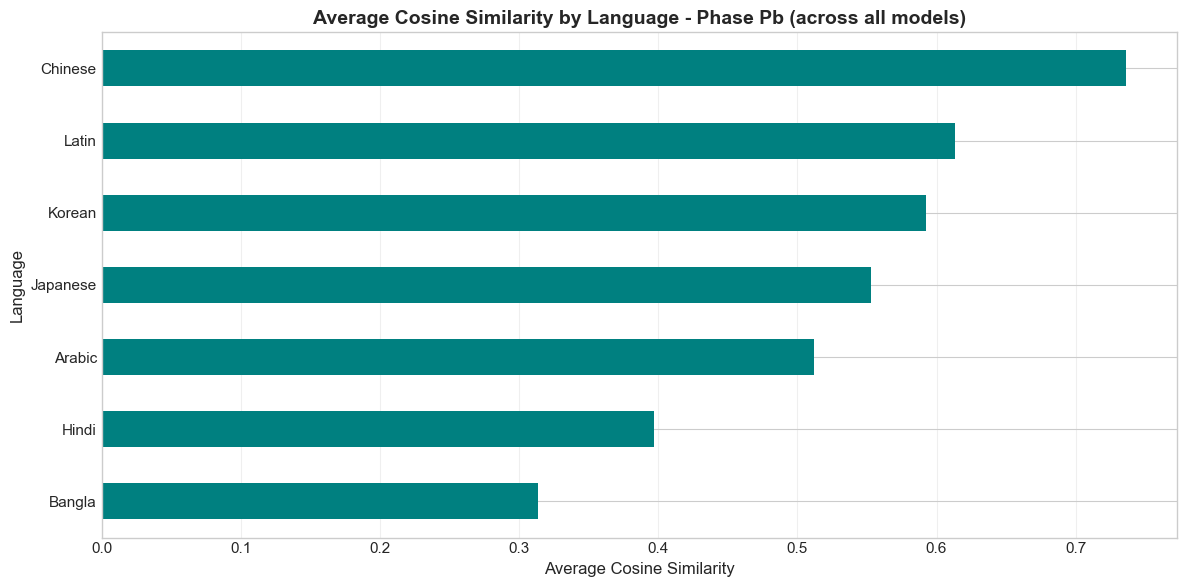


PHASE Pc VISUALIZATIONS



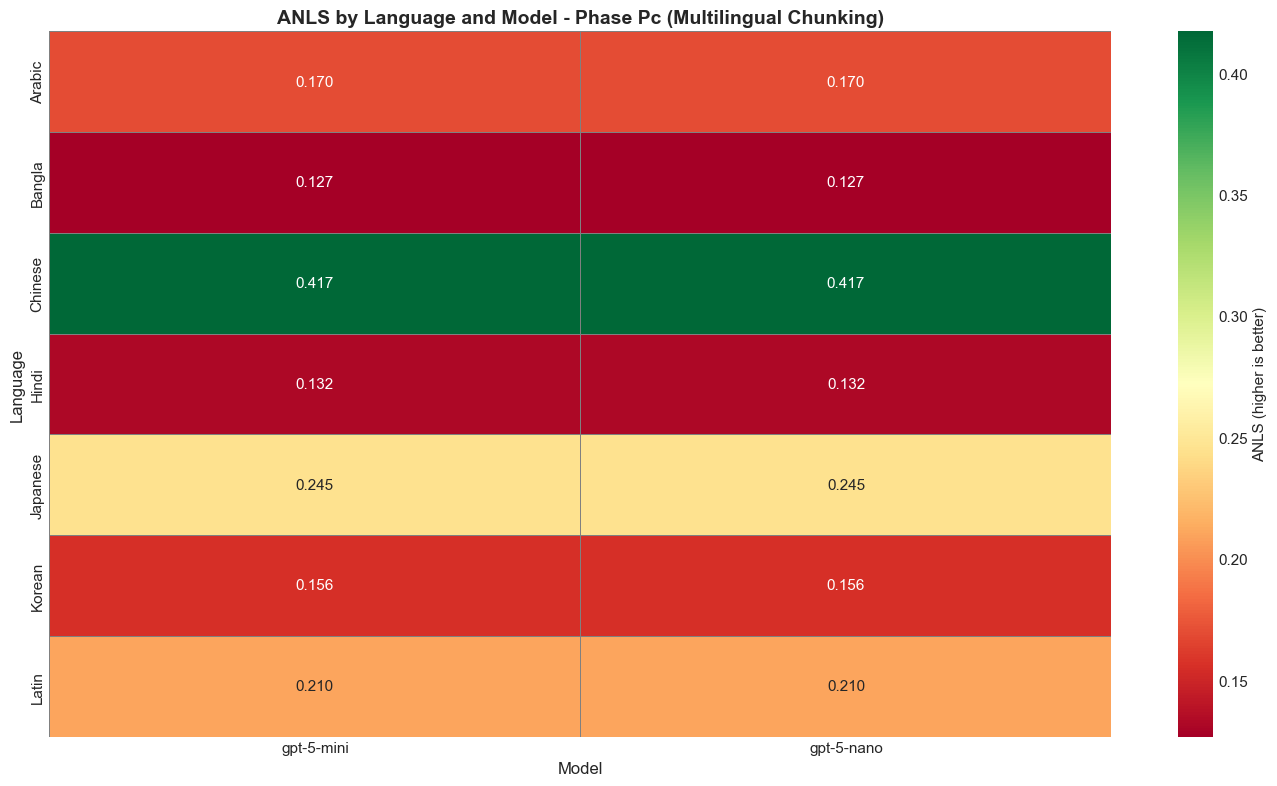

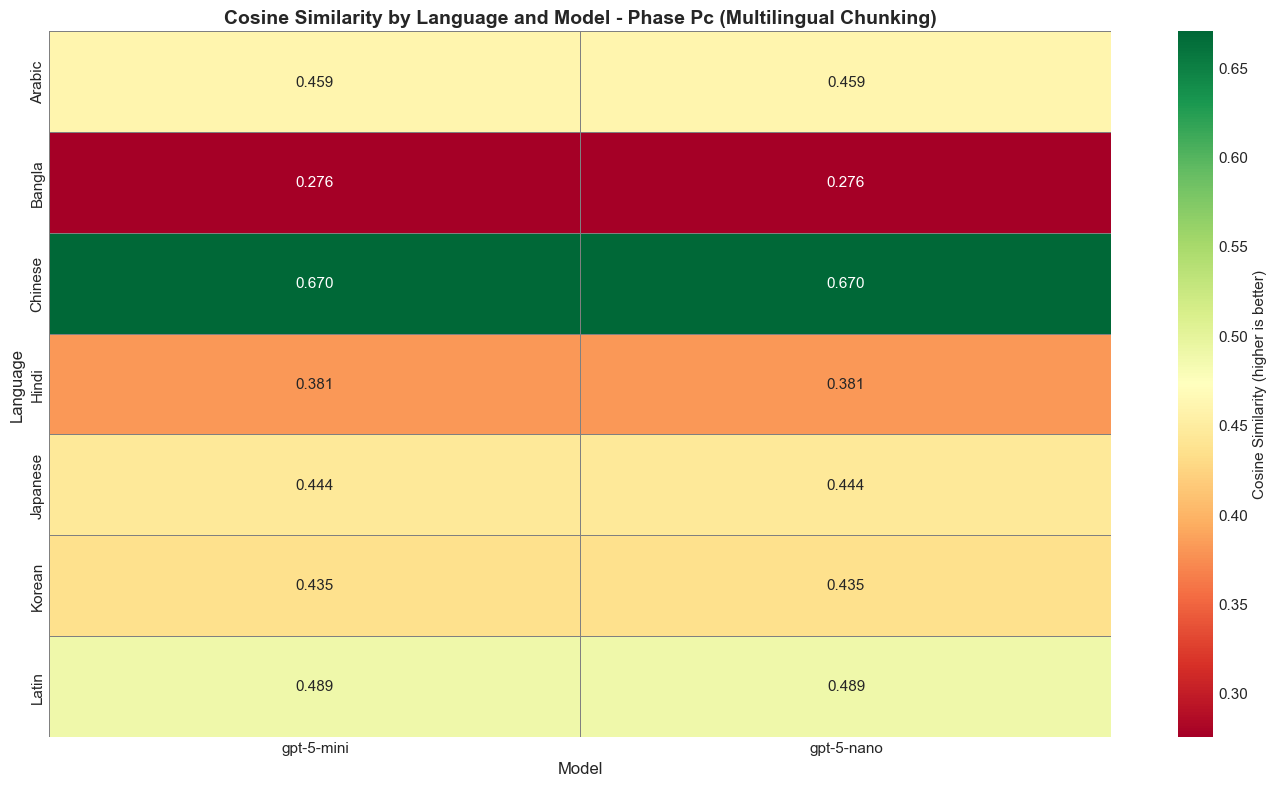

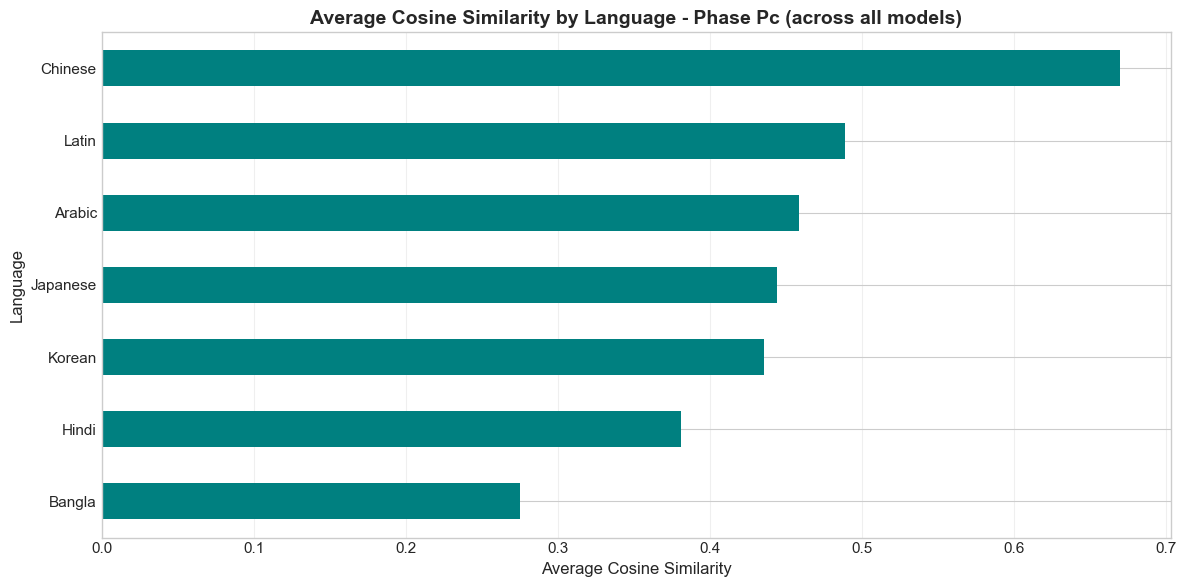

In [98]:
# Analyze cosine similarity by language (with chunking for long texts)
if 'language' in df_results.columns:
    # Explode language combinations into individual languages
    import re
    def split_languages(lang_str):
        if pd.isna(lang_str):
            return []
        # Split on common delimiters: comma, semicolon, pipe, slash, whitespace
        langs = [l.strip() for l in re.split(r'[;,|/\s]+', str(lang_str)) if l.strip()]
        # Filter out unwanted and non-alphabetic (symbols)
        valid_langs = []
        for l in langs:
            l_lower = l.lower()
            if l_lower in ['none', 'mixed']:
                continue
            if not l.isalpha():
                continue  # Delete symbols/numbers
            valid_langs.append(l)
        return valid_langs
    
    df_exploded = df_results.copy()
    df_exploded['language_list'] = df_exploded['language'].apply(split_languages)
    df_exploded = df_exploded.explode('language_list').dropna(subset=['language_list'])
    df_exploded = df_exploded[df_exploded['language_list'] != '']
    
    # Filter out 'symbols' language
    df_exploded = df_exploded[df_exploded['language_list'].str.lower() != 'symbols']
    
    # Get unique individual languages
    unique_langs = sorted(df_exploded['language_list'].unique())
    
    if len(unique_langs) > 0:
        # Aggregate metrics by language, model, and phase
        df_lang_cosine = df_exploded.groupby(['language_list', 'model', 'phase']).agg({
            'anls': ['mean', 'std'],
            'cosine_similarity': ['mean', 'std'],
            'sample_id': 'count'
        }).round(4)
        
        df_lang_cosine.columns = ['_'.join(col).strip() for col in df_lang_cosine.columns.values]
        df_lang_cosine = df_lang_cosine.rename(columns={'sample_id_count': 'n_samples'})
        df_lang_cosine = df_lang_cosine.reset_index()
        df_lang_cosine = df_lang_cosine.rename(columns={'language_list': 'language'})
        
        print("ANLS and Cosine Similarity by Language, Model, and Phase:")
        print("Note: Texts >300 chars use chunked similarity (150-char chunks, 30-char overlap)")
        display(df_lang_cosine.sort_values(['phase', 'language', 'anls_mean'], ascending=[True, True, False]))
        
        # Create visualizations for each phase
        for phase in ['Pa', 'Pb', 'Pc']:
            phase_data = df_lang_cosine[df_lang_cosine['phase'] == phase]
            
            if len(phase_data) > 0:
                print(f"\n{'='*80}")
                print(f"PHASE {phase} VISUALIZATIONS")
                print(f"{'='*80}\n")
                
                # Visualization 1: ANLS by Language for this phase
                fig, ax = plt.subplots(figsize=(14, 8))
                
                df_pivot_anls = phase_data.pivot_table(index='language', columns='model', values='anls_mean', aggfunc='mean')
                
                sns.heatmap(df_pivot_anls, annot=True, fmt='.3f', cmap='RdYlGn', 
                            cbar_kws={'label': 'ANLS (higher is better)'}, ax=ax,
                            linewidths=0.5, linecolor='gray')
                ax.set_title(f'ANLS by Language and Model - Phase {phase} (Multilingual Chunking)', 
                             fontsize=14, fontweight='bold')
                ax.set_xlabel('Model', fontsize=12)
                ax.set_ylabel('Language', fontsize=12)
                plt.tight_layout()
                plt.show()
                
                # Visualization 2: Cosine Similarity by Language for this phase
                fig, ax = plt.subplots(figsize=(14, 8))
                
                df_pivot_cosine = phase_data.pivot_table(index='language', columns='model', values='cosine_similarity_mean', aggfunc='mean')
                
                sns.heatmap(df_pivot_cosine, annot=True, fmt='.3f', cmap='RdYlGn', 
                            cbar_kws={'label': 'Cosine Similarity (higher is better)'}, ax=ax,
                            linewidths=0.5, linecolor='gray')
                ax.set_title(f'Cosine Similarity by Language and Model - Phase {phase} (Multilingual Chunking)', 
                             fontsize=14, fontweight='bold')
                ax.set_xlabel('Model', fontsize=12)
                ax.set_ylabel('Language', fontsize=12)
                plt.tight_layout()
                plt.show()
                
                # Visualization 3: Bar chart showing average cosine similarity per language for this phase
                avg_cosine_by_lang = phase_data.groupby('language')['cosine_similarity_mean'].mean().sort_values()
                
                fig, ax = plt.subplots(figsize=(12, 6))
                avg_cosine_by_lang.plot(kind='barh', ax=ax, color='teal')
                ax.set_title(f'Average Cosine Similarity by Language - Phase {phase} (across all models)', 
                             fontsize=14, fontweight='bold')
                ax.set_xlabel('Average Cosine Similarity', fontsize=12)
                ax.set_ylabel('Language', fontsize=12)
                ax.grid(axis='x', alpha=0.3)
                plt.tight_layout()
                plt.show()
    else:
        print("No valid languages found for cosine similarity analysis")
else:
    print("No 'language' column found in results")

### Average across all phases

ANLS and Cosine Similarity by Language, Model, and Phase:
Note: Texts >300 chars use chunked similarity (150-char chunks, 30-char overlap)


,language,model,phase,anls_mean,anls_std,cosine_similarity_mean,cosine_similarity_std,n_samples
0,Arabic,azure_intelligence,Pa,0.0463,0.1570,0.4225,0.2688,159
5,Arabic,mistral_document_ai,Pa,0.0463,0.1570,0.4225,0.2688,159
6,Bangla,azure_intelligence,Pa,0.0215,0.1079,0.2498,0.1806,154
11,Bangla,mistral_document_ai,Pa,0.0215,0.1079,0.2498,0.1806,154
12,Chinese,azure_intelligence,Pa,0.1336,0.2720,0.5398,0.3046,181
17,Chinese,mistral_document_ai,Pa,0.1336,0.2720,0.5398,0.3046,181
18,Hindi,azure_intelligence,Pa,0.1107,0.2694,0.3665,0.2628,152
23,Hindi,mistral_document_ai,Pa,0.1107,0.2694,0.3665,0.2628,152
24,Japanese,azure_intelligence,Pa,0.0669,0.2100,0.4690,0.2883,228
29,Japanese,mistral_document_ai,Pa,0.0669,0.2100,0.4690,0.2883,228


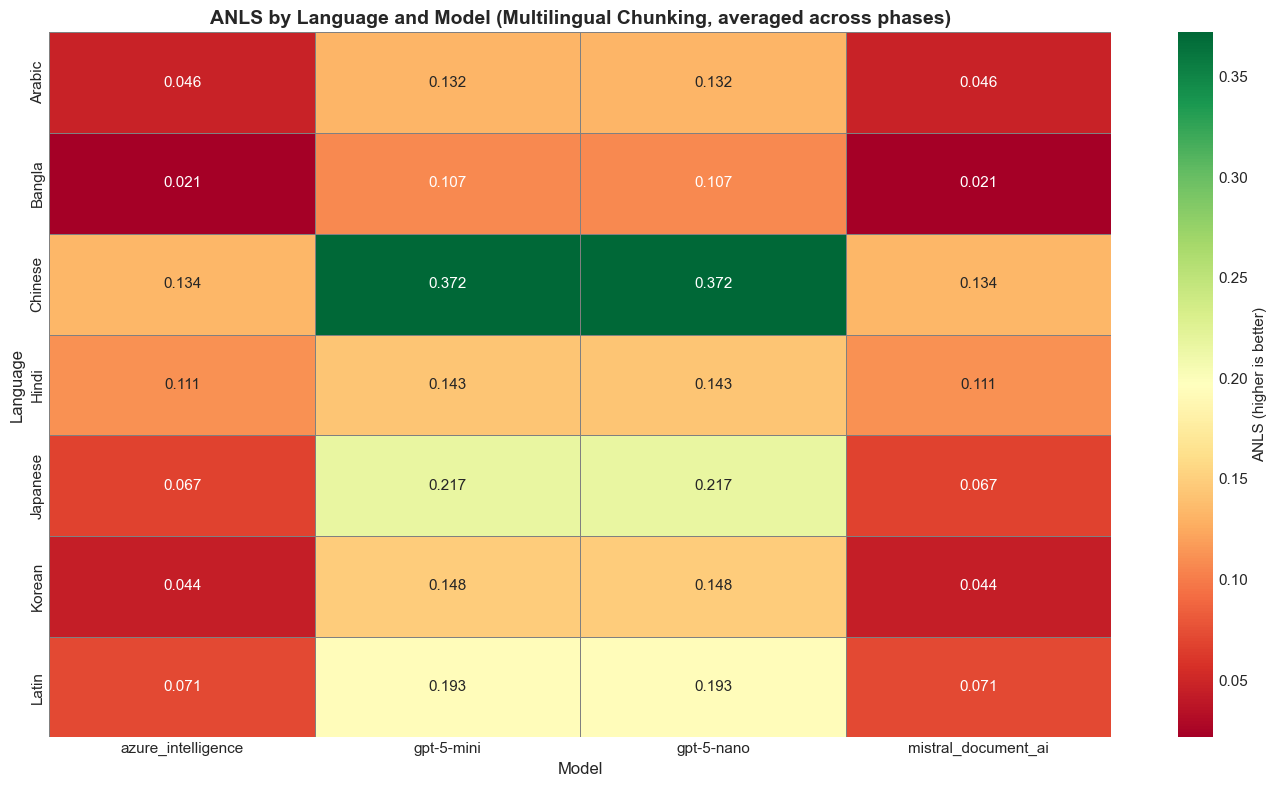

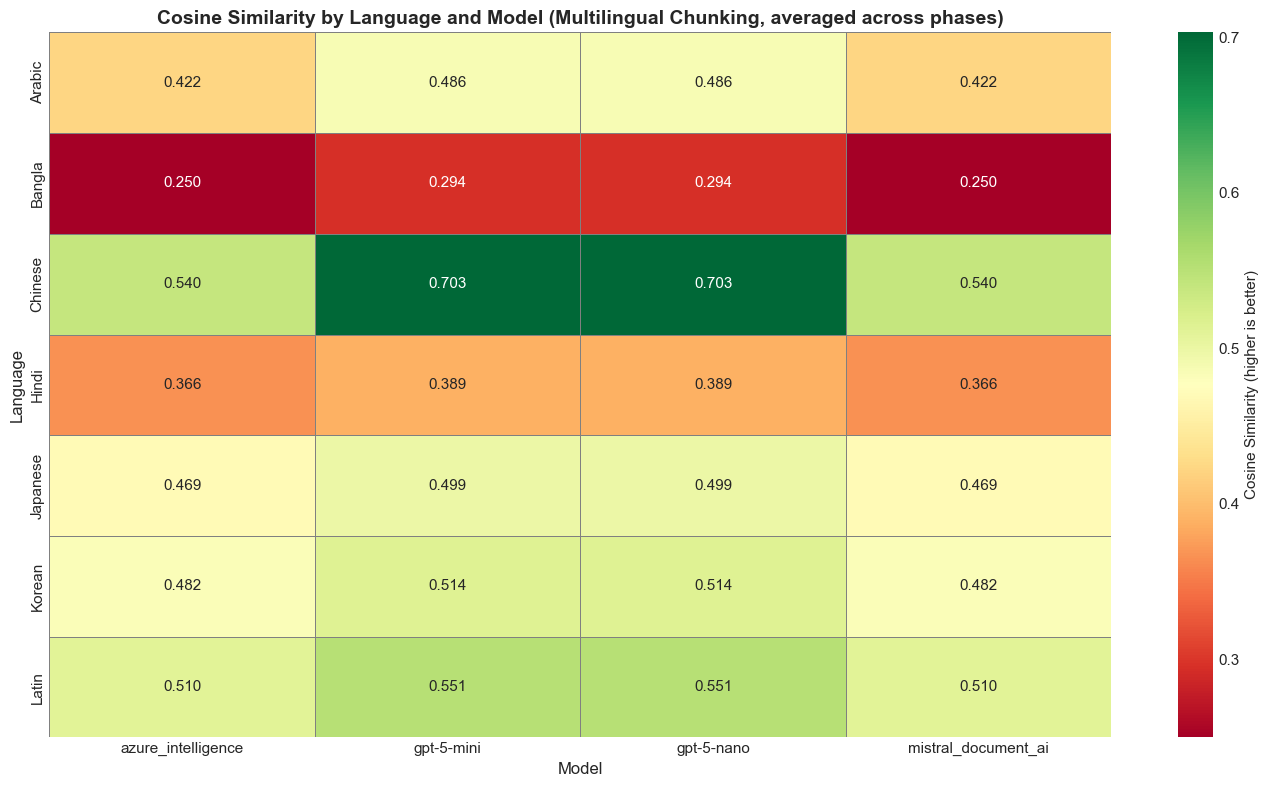

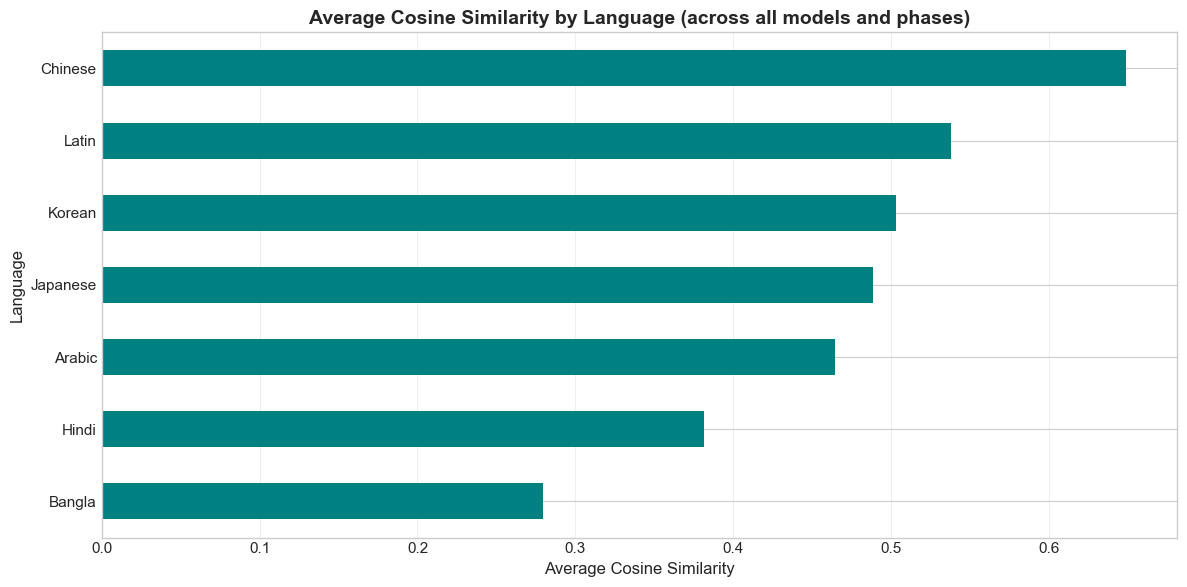

In [99]:
# Analyze cosine similarity by language (with chunking for long texts)
if 'language' in df_results.columns:
    # Explode language combinations into individual languages
    import re
    def split_languages(lang_str):
        if pd.isna(lang_str):
            return []
        # Split on common delimiters: comma, semicolon, pipe, slash, whitespace
        langs = [l.strip() for l in re.split(r'[;,|/\s]+', str(lang_str)) if l.strip()]
        # Filter out unwanted and non-alphabetic (symbols)
        valid_langs = []
        for l in langs:
            l_lower = l.lower()
            if l_lower in ['none', 'mixed']:
                continue
            if not l.isalpha():
                continue  # Delete symbols/numbers
            valid_langs.append(l)
        return valid_langs
    
    df_exploded = df_results.copy()
    df_exploded['language_list'] = df_exploded['language'].apply(split_languages)
    df_exploded = df_exploded.explode('language_list').dropna(subset=['language_list'])
    df_exploded = df_exploded[df_exploded['language_list'] != '']
    
    # Filter out 'symbols' language
    df_exploded = df_exploded[df_exploded['language_list'].str.lower() != 'symbols']
    
    # Get unique individual languages
    unique_langs = sorted(df_exploded['language_list'].unique())
    
    if len(unique_langs) > 0:
        # Aggregate metrics by language, model, and phase
        df_lang_cosine = df_exploded.groupby(['language_list', 'model', 'phase']).agg({
            'anls': ['mean', 'std'],
            'cosine_similarity': ['mean', 'std'],
            'sample_id': 'count'
        }).round(4)
        
        df_lang_cosine.columns = ['_'.join(col).strip() for col in df_lang_cosine.columns.values]
        df_lang_cosine = df_lang_cosine.rename(columns={'sample_id_count': 'n_samples'})
        df_lang_cosine = df_lang_cosine.reset_index()
        df_lang_cosine = df_lang_cosine.rename(columns={'language_list': 'language'})
        
        print("ANLS and Cosine Similarity by Language, Model, and Phase:")
        print("Note: Texts >300 chars use chunked similarity (150-char chunks, 30-char overlap)")
        display(df_lang_cosine.sort_values(['phase', 'language', 'anls_mean'], ascending=[True, True, False]))
        
        # Visualization 1: ANLS by Language (averaged across phases)
        fig, ax = plt.subplots(figsize=(14, 8))
        
        df_pivot_anls = df_lang_cosine.pivot_table(index='language', columns='model', values='anls_mean', aggfunc='mean')
        
        sns.heatmap(df_pivot_anls, annot=True, fmt='.3f', cmap='RdYlGn', 
                    cbar_kws={'label': 'ANLS (higher is better)'}, ax=ax,
                    linewidths=0.5, linecolor='gray')
        ax.set_title('ANLS by Language and Model (Multilingual Chunking, averaged across phases)', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel('Language', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        # Visualization 2: Cosine Similarity by Language (averaged across phases)
        fig, ax = plt.subplots(figsize=(14, 8))
        
        df_pivot_cosine = df_lang_cosine.pivot_table(index='language', columns='model', values='cosine_similarity_mean', aggfunc='mean')
        
        sns.heatmap(df_pivot_cosine, annot=True, fmt='.3f', cmap='RdYlGn', 
                    cbar_kws={'label': 'Cosine Similarity (higher is better)'}, ax=ax,
                    linewidths=0.5, linecolor='gray')
        ax.set_title('Cosine Similarity by Language and Model (Multilingual Chunking, averaged across phases)', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel('Language', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        # Bar chart showing average cosine similarity per language
        avg_cosine_by_lang = df_lang_cosine.groupby('language')['cosine_similarity_mean'].mean().sort_values()
        
        fig, ax = plt.subplots(figsize=(12, 6))
        avg_cosine_by_lang.plot(kind='barh', ax=ax, color='teal')
        ax.set_title('Average Cosine Similarity by Language (across all models and phases)', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Average Cosine Similarity', fontsize=12)
        ax.set_ylabel('Language', fontsize=12)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid languages found for cosine similarity analysis")
else:
    print("No 'language' column found in results")

### Phase Comparison - Impact of Context

Compare VLM performance across phases to assess the impact of task-aware prompting.

# Save Embeddings Cache

Save newly computed embeddings to disk for faster future runs.

In [100]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {', '.join(embedding_manager.modified_phases)}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
    print(f"📂 Location: {EMBEDDINGS_DIR.resolve()}")
    print("   Next run will load these embeddings from cache (much faster!)")
else:
    print("✅ No new embeddings to save (all from cache)")
    
# Print final cache statistics
embedding_manager.print_statistics()


📁 Finalizing embedding cache...
✅ No new embeddings to save (all from cache)

📊 Embedding Cache Statistics:
   Cache hits: 19648
   Cache misses: 0
   Hit rate: 100.0%


### Summary Statistics Export

In [101]:
# Export key statistics for LLM analysis
summary = {
    'dataset': 'ICDAR_mini',
    'n_samples': len(df_pa),
    'n_languages': df_results['language'].nunique(),
    'languages': sorted(df_results['language'].unique().tolist()),
    'models': {
        'ocr': models_pa,
        'vlm_baseline': models_pb,
        'vlm_context': models_pc
    },
    'best_overall': df_overall.index[0],
    'best_cer': df_overall['cer'].min(),
    'metrics': df_agg.to_dict('records')
}

print("Summary Statistics:")
print(json.dumps(summary, indent=2))

# Optionally save to file
# with open('icdar_summary.json', 'w') as f:
#     json.dump(summary, f, indent=2)

Summary Statistics:
{
  "dataset": "ICDAR_mini",
  "n_samples": 491,
  "n_languages": 65,
  "languages": [
    "Arabic",
    "Bangla",
    "Bangla, Latin",
    "Chinese",
    "Chinese, Japanese, Korean, Latin",
    "Chinese, Latin",
    "Chinese, Mixed",
    "Chinese, Mixed, Latin",
    "Chinese, None, Latin",
    "Chinese, None, Mixed, Latin",
    "Chinese, Symbols, Latin",
    "Hindi",
    "Hindi, Latin",
    "Japanese",
    "Japanese, Korean, Latin",
    "Japanese, Korean, Latin, Mixed",
    "Japanese, Korean, Latin, Symbols",
    "Japanese, Latin",
    "Japanese, Latin, Mixed",
    "Japanese, Latin, Symbols, Mixed",
    "Japanese, Mixed, Korean, Latin, None",
    "Japanese, Symbols, Korean, Latin, None",
    "Japanese, Symbols, Mixed, Latin, None",
    "Korean",
    "Korean, Latin",
    "Latin",
    "Latin, Arabic",
    "Mixed",
    "Mixed, Hindi, Latin",
    "Mixed, Japanese",
    "Mixed, Korean",
    "Mixed, Korean, Latin",
    "Mixed, Korean, Latin, Japanese",
    "Mixed, Latin,